# Microgrid Optimization

Created by: Thananop Kullapan

## **Part #1 Data Construction**

### **1.1 Importing and Verifying Meteorological Data**

To accurately model the renewable energy generation potential, we utilize satellite-derived meteorological data sourced from the Renewables.ninja platform, specifically for the `Phuket` region. The primary variable of interest is swgdn (Shortwave downward radiation), which serves as our `Global Horizontal Irradiance (GHI)` measured in W/m². Since the raw file contains three rows of technical metadata at the top, the extraction process automatically skips these rows to maintain data frame integrity. We also standardize the timestamp to local time without timezone offsets to ensure smooth merging with local operational data.

Open Source: https://www.renewables.ninja/

In [119]:
url = 'https://raw.githubusercontent.com/SKY-TKP/PROJECT/refs/heads/main/python/microgrid/dataset/ninja_weather_7.9366_98.3529_uncorrected.csv'

In [120]:
import pandas as pd

# Define the uploaded file name

# Read the file, skipping the first 3 rows of metadata
df_solar = pd.read_csv(url, skiprows=3)
df_solar.head()

,time,local_time,t2m,prectotland,precsnoland,snomas,rhoa,swgdn,swtdn,cldtot
0,2025-01-01 00:00,2025-01-01 07:00,25.706,0.0,0,0,1.169,139.933,273.458,0.728
1,2025-01-01 01:00,2025-01-01 08:00,26.229,0.0,0,0,1.168,364.096,580.324,0.724
2,2025-01-01 02:00,2025-01-01 09:00,26.838,0.0,0,0,1.166,565.720,842.285,0.733
3,2025-01-01 03:00,2025-01-01 10:00,27.319,0.0,0,0,1.164,717.151,1041.814,0.727
4,2025-01-01 04:00,2025-01-01 11:00,27.722,0.0,0,0,1.162,828.631,1165.078,0.729


In [121]:
# Filter and rename crucial columns
df_solar = df_solar[['local_time', 'swgdn']].copy()
df_solar.rename(columns={'local_time': 'Datetime', 'swgdn': 'Solar_W_m2'}, inplace=True)

# Convert to datetime and remove timezone information
df_solar['Datetime'] = pd.to_datetime(df_solar['Datetime']).dt.tz_localize(None)
df_solar.set_index('Datetime', inplace=True)

# Data Verification
print("--- Data Information ---")
df_solar.info()

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2025-01-01 07:00:00 to 2026-01-01 06:00:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Solar_W_m2  8760 non-null   float64
dtypes: float64(1)
memory usage: 136.9 KB


In [122]:
print("--- Summary Statistics ---")
display(df_solar.describe())

--- Summary Statistics ---


,Solar_W_m2
count,8760.000000
mean,187.403199
std,260.350292
min,0.000000
25%,0.000000
50%,8.650500
75%,350.618000
max,1025.674000


In [123]:
print("--- Missing Values Check ---")
print(df_solar.isnull().sum())

--- Missing Values Check ---
Solar_W_m2    0
dtype: int64


In [124]:
print("--- Data Head ---")
display(df_solar.head())

--- Data Head ---


,Solar_W_m2
Datetime,
2025-01-01 07:00:00,139.933
2025-01-01 08:00:00,364.096
2025-01-01 09:00:00,565.720
2025-01-01 10:00:00,717.151
2025-01-01 11:00:00,828.631


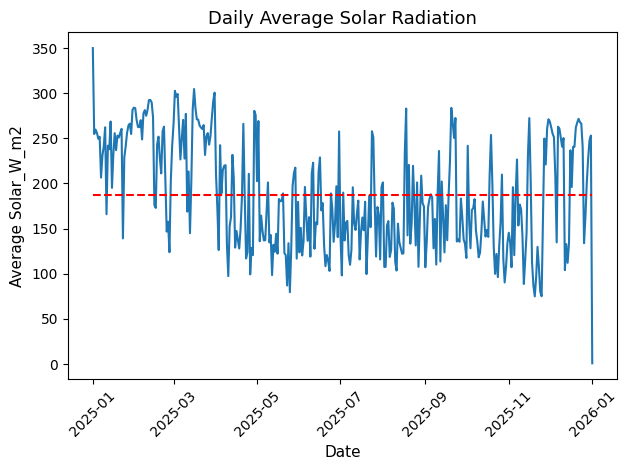

In [125]:
import matplotlib.pyplot as plt

# Resample to daily average
daily_avg = df_solar.resample('D').mean()

# plot
plt.figure()
plt.plot(daily_avg.index, daily_avg['Solar_W_m2'])
plt.xlabel('Date')
plt.ylabel('Average Solar_W_m2')
plt.hlines(y=daily_avg['Solar_W_m2'].mean(), xmin=daily_avg.index.min(), xmax=daily_avg.index.max(), linestyles='dashed', colors='r')
plt.title('Daily Average Solar Radiation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

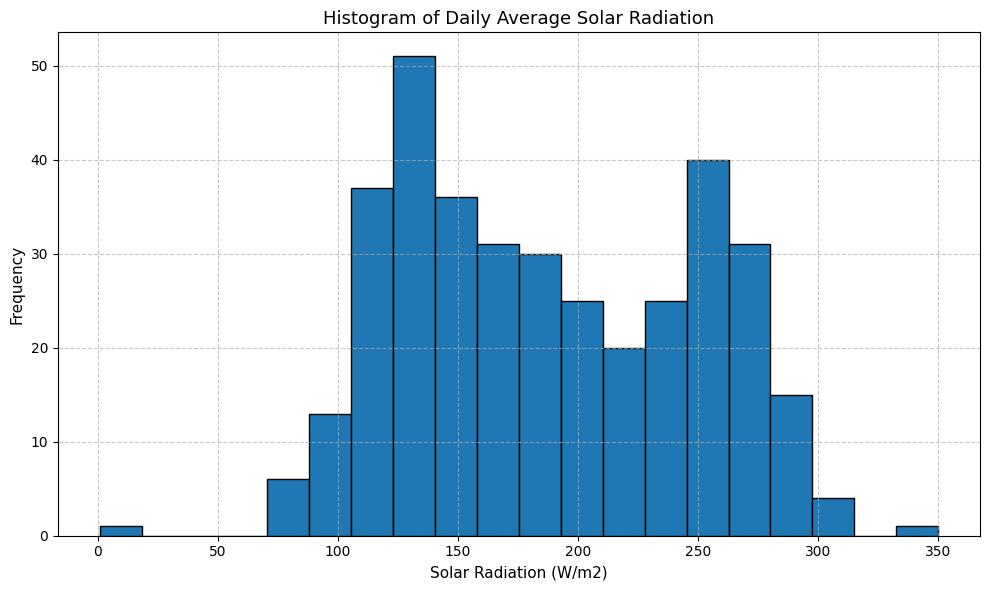

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(daily_avg['Solar_W_m2'], bins=20, edgecolor='black')
plt.title('Histogram of Daily Average Solar Radiation')
plt.xlabel('Solar Radiation (W/m2)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **1.2 Generating the Factory Demand Profile**

Since high-resolution corporate energy data is highly confidential, we construct a reference hourly load profile for a simulated industrial facility. The base assumption is a standard operational shift: peak energy consumption (1,200 kW) occurs during working hours (08:00 - 18:00), while idle hours maintain a baseline load (400 kW). To mimic real-world electrical volatility, we inject random Gaussian noise. Furthermore, standard data forecasting logic is applied to handle anomalous drops: any simulated demand value falling below 80% of the overall average is automatically replaced with the average value to ensure the optimization solver isn't biased by extreme, unrealistic outliers.

In [127]:
import numpy as np

# Generate a full year of hourly timestamps (8,760 hours)
dates = pd.date_range(start='2025-01-01', end='2025-12-31 23:00:00', freq='h')
df_demand = pd.DataFrame(index=dates)

# Establish Base Load: 1200 kW during daytime (8-18), 400 kW otherwise
hours = df_demand.index.hour
base_load = np.where((hours >= 8) & (hours <= 18), 1200, 400)

# Inject Gaussian noise for realistic fluctuations
np.random.seed(42)
noise = np.random.normal(loc=0, scale=150, size=len(df_demand))
demand_noisy = base_load + noise

# Apply demand correction logic: replace values < 80% of average with the average itself
avg_demand = np.mean(demand_noisy)
threshold_limit = 0.8 * avg_demand
df_demand['Demand_kW'] = np.where(demand_noisy < threshold_limit, avg_demand, demand_noisy)

# Round to 2 decimal places for cleaner data
df_demand['Demand_kW'] = np.round(df_demand['Demand_kW'], 2)

# Export to CSV
demand_filename = 'factory_demand_profile.csv'
df_demand.to_csv(demand_filename)

print(f"Successfully generated and saved: {demand_filename}")
print("\n--- Demand Data Head ---")
display(df_demand.head())

Successfully generated and saved: factory_demand_profile.csv

--- Demand Data Head ---


,Demand_kW
2025-01-01 00:00:00,766.58
2025-01-01 01:00:00,766.58
2025-01-01 02:00:00,766.58
2025-01-01 03:00:00,628.45
2025-01-01 04:00:00,766.58


In [128]:
df_demand

,Demand_kW
2025-01-01 00:00:00,766.58
2025-01-01 01:00:00,766.58
2025-01-01 02:00:00,766.58
2025-01-01 03:00:00,628.45
2025-01-01 04:00:00,766.58
...,...
2025-12-31 19:00:00,766.58
2025-12-31 20:00:00,766.58
2025-12-31 21:00:00,766.58
2025-12-31 22:00:00,766.58


array([[<Axes: title={'center': 'Demand_kW'}>]], dtype=object)

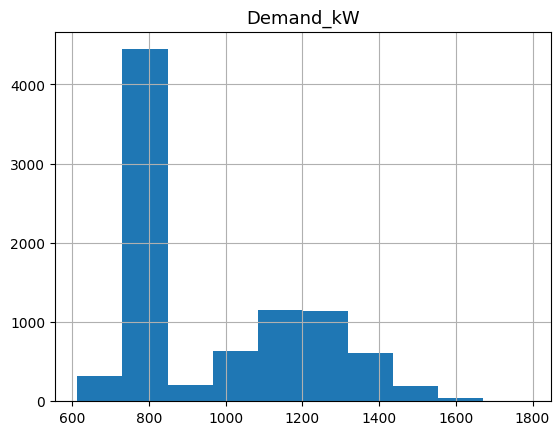

In [129]:
df_demand.hist()

### **1.3 Building the Single Source of Truth (SSOT)**

To deploy the prescriptive stochastic optimization model, all relevant parameters must be unified into a **Single Source of Truth** (SSOT) data frame. This step merges the weather generation limits and the facility demand constraints using a strict inner join on the hourly datetime index. Crucially, we integrate the official Thai Provincial Electricity Authority (PEA) Time-of-Use (TOU) tariff (Type 4) into the dataset. By explicitly defining the `On-Peak (4.1839 THB)` and `Off-Peak (2.6037 THB)` pricing windows, we establish the economic environment that will force the mathematical solver to perform peak shaving and load shifting.

In [130]:
# Load the newly created demand profile
df_demand_input = pd.read_csv('factory_demand_profile.csv')
df_demand_input.rename(columns={'Unnamed: 0': 'Datetime'}, inplace=True)
df_demand_input['Datetime'] = pd.to_datetime(df_demand_input['Datetime'])
df_demand_input.set_index('Datetime', inplace=True)

# Merge datasets using an Inner Join to ensure exact timestamp alignment
df_ssot = df_solar.join(df_demand_input, how='inner')

# Inject PEA TOU Tariff logic
df_ssot['DayOfWeek'] = df_ssot.index.dayofweek
df_ssot['Hour'] = df_ssot.index.hour

# Define base Off-Peak price
df_ssot['Grid_Price_THB'] = 2.6037

# Define On-Peak condition: Weekdays (Mon-Fri) AND Hours (09:00 to 21:59)
on_peak_condition = (df_ssot['DayOfWeek'] <= 4) & (df_ssot['Hour'] >= 9) & (df_ssot['Hour'] < 22)
df_ssot.loc[on_peak_condition, 'Grid_Price_THB'] = 4.1839

In [131]:
# Clean up temporary structural columns
df_ssot.drop(columns=['DayOfWeek', 'Hour'], inplace=True)

print("--- SSOT Successfully Constructed ---")
print(f"Final Data Shape: {df_ssot.shape}")
print("\n--- SSOT Data Head ---")
display(df_ssot.head(15)) # Displaying 15 rows to show the transition into On-Peak pricing

--- SSOT Successfully Constructed ---
Final Data Shape: (8753, 3)

--- SSOT Data Head ---


,Solar_W_m2,Demand_kW,Grid_Price_THB
Datetime,,,
2025-01-01 07:00:00,139.933,766.58,2.6037
2025-01-01 08:00:00,364.096,1129.58,2.6037
2025-01-01 09:00:00,565.720,1281.38,4.1839
2025-01-01 10:00:00,717.151,1130.49,4.1839
2025-01-01 11:00:00,828.631,1130.14,4.1839
2025-01-01 12:00:00,883.325,1236.29,4.1839
2025-01-01 13:00:00,853.506,913.01,4.1839
2025-01-01 14:00:00,727.071,941.26,4.1839
2025-01-01 15:00:00,511.488,1115.66,4.1839


## **Part #2 Mathematical Formulation for Microgrid Optimization**


### **Model 1: Simple Model**

In this phase, we transition from the raw data (SSOT) to a prescriptive **Mixed-Integer Linear Programming (MILP)** model. The formulation utilizes a Two-Stage Decision framework:
1. **Stage 1 (Sizing):** Strategic investment decisions to determine the optimal system capacities (Here-and-Now Decisions).
2. **Stage 2 (Dispatch):** Hourly operational decisions to minimize costs under the Time-of-Use (TOU) tariff constraints (Wait-and-See Decisions).

#### **2.1.1 Parameters (Input Data)**
These are deterministic constants derived directly from our SSOT dataframe:
* $D_t$: Electrical demand of the facility at time $t$ (kW).
* $GHI_t$: Global Horizontal Irradiance (Solar intensity) at time $t$ (W/m²).
* $C^{grid}_t$: Grid electricity price from the Provincial Electricity Authority (PEA TOU tariff) at time $t$ (THB/kWh).
* $C^{solar}_{capex}$: Annualized capital expenditure per unit of Solar PV (THB/kW).
* $C^{batt}_{capex}$: Annualized capital expenditure per unit of Battery Storage (THB/kWh).
* $\eta$: Battery round-trip efficiency for charging and discharging (Assumed at 0.95 or 95%).

---

#### **2.1.2 Decision Variables**
These are the variables the optimization solver will calculate to find the optimal global solution.

**Stage 1 Variables (Continuous - Investment):**
* $S_{solar}$: Total installed capacity of the Solar PV system (kW).
* $S_{batt}$: Total installed capacity of the Battery Energy Storage System (kWh).

**Stage 2 Variables (Continuous - Hourly Operations):**
* $P^{grid}_t$: Power purchased from the utility grid at time $t$ (kW).
* $P^{solar\_use}_t$: Solar power consumed directly by the facility at time $t$ (kW).
* $P^{ch}_t$: Power charged into the battery at time $t$ (kW).
* $P^{dis}_t$: Power discharged from the battery to the facility at time $t$ (kW).
* $SOC_t$: State of Charge (energy currently stored in the battery) at time $t$ (kWh).

---


#### **2.1.3 Objective Function**
**Goal:** Minimize the Total Cost of Ownership (TCO). This is the sum of the system's capital expenditure (CAPEX) and the operational grid electricity costs (OPEX) across the modeled time horizon.

$$\min Z = \left( C^{solar}_{capex} S_{solar} + C^{batt}_{capex} S_{batt} \right) + \sum_{t \in T} \left( C^{grid}_t P^{grid}_t \right)$$

---


#### **2.1.4 Constraints**
The model must strictly adhere to the following physical and business logic boundaries:

**1. Energy Balance Constraint:**
The total power supply must exactly equal the total power demand (facility load + battery charging) at every hour.
$$P^{grid}_t + P^{solar\_use}_t + P^{dis}_t = D_t + P^{ch}_t \quad \forall t \in T$$

**2. Solar Generation Limit:**
The combined solar power used directly and charged into the battery cannot exceed the physical generation potential of the installed panels based on hourly weather data.
$$P^{solar\_use}_t + P^{ch}_t \leq S_{solar} \times \left( \frac{GHI_t}{1000} \right) \quad \forall t \in T$$

**3. Battery State of Charge (SOC) Dynamics:**
The energy stored in the battery at the current hour equals the energy from the previous hour, plus charged energy, minus discharged energy (accounting for efficiency losses).
$$SOC_t = SOC_{t-1} + (P^{ch}_t \times \eta) - \left( \frac{P^{dis}_t}{\eta} \right) \quad \forall t \in T$$

**4. Battery Capacity Limit:**
The energy stored in the battery at any time cannot exceed the total installed battery capacity determined in Stage 1.
$$SOC_t \leq S_{batt} \quad \forall t \in T$$

---


#### **2.1.5 Python Code**

In [132]:
# Install required libraries if not already installed
!pip install -q pyomo
!apt-get install -y -qq glpk-utils

In [133]:
import pyomo.environ as pyo

def build_and_solve_microgrid(df):
    print("Building Mathematical Optimization Model...")
    m = pyo.ConcreteModel()

    # 1. Sets
    m.T = pyo.RangeSet(0, len(df)-1)

    # 2. Parameters (Annualized Weekly Costs for Demo Purposes)
    # Assuming ~30,000 THB/kW over 20 years for Solar -> ~28 THB/week
    capex_solar_wk = 28.0
    capex_batt_wk = 28.0
    efficiency = 0.95

    # 3. Decision Variables (Stage 1 & 2)
    m.S_solar = pyo.Var(within=pyo.NonNegativeReals)
    m.S_batt = pyo.Var(within=pyo.NonNegativeReals)

    m.P_grid = pyo.Var(m.T, within=pyo.NonNegativeReals)
    m.P_solar_use = pyo.Var(m.T, within=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.T, within=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.T, within=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.T, within=pyo.NonNegativeReals)

    # 4. Constraints
    def energy_balance_rule(m, t):
        return m.P_grid[t] + m.P_solar_use[t] + m.P_dis[t] == df['Demand_kW'].iloc[t] + m.P_ch[t]
    m.c_energy = pyo.Constraint(m.T, rule=energy_balance_rule)

    def solar_limit_rule(m, t):
        solar_yield = df['Solar_W_m2'].iloc[t] / 1000.0
        return m.P_solar_use[t] + m.P_ch[t] <= m.S_solar * solar_yield
    m.c_solar = pyo.Constraint(m.T, rule=solar_limit_rule)

    def soc_rule(m, t):
        if t == 0:
            return m.SOC[t] == (m.P_ch[t] * efficiency) - (m.P_dis[t] / efficiency)
        else:
            return m.SOC[t] == m.SOC[t-1] + (m.P_ch[t] * efficiency) - (m.P_dis[t] / efficiency)
    m.c_soc = pyo.Constraint(m.T, rule=soc_rule)

    def soc_cap_rule(m, t):
        return m.SOC[t] <= m.S_batt
    m.c_soc_cap = pyo.Constraint(m.T, rule=soc_cap_rule)

    # 5. Objective Function
    def objective_rule(m):
        capex = (m.S_solar * capex_solar_wk) + (m.S_batt * capex_batt_wk)
        opex = sum(m.P_grid[t] * df['Grid_Price_THB'].iloc[t] for t in m.T)
        return capex + opex
    m.Obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    # 6. Solve Model
    print("Solving MILP with GLPK...")
    solver = pyo.SolverFactory('glpk')
    results = solver.solve(m, tee=False)

    print("-" * 30)
    print(f"Solver Status: {results.solver.status}")
    print(f"Optimal Solar Capacity: {pyo.value(m.S_solar):.2f} kW")
    print(f"Optimal Battery Capacity: {pyo.value(m.S_batt):.2f} kWh")
    print(f"Total Minimized Cost: {pyo.value(m.Obj):.2f} THB")

    return m

In [134]:
# To execute, simply call the function with your SSOT dataframe:
m_solved = build_and_solve_microgrid(df_ssot)

Building Mathematical Optimization Model...
Solving MILP with GLPK...
------------------------------
Solver Status: ok
Optimal Solar Capacity: 14729.71 kW
Optimal Battery Capacity: 11563.07 kWh
Total Minimized Cost: 804891.49 THB


### **Model 2: Stochastic Programming**

To prevent structural conflicts with our initial deterministic baseline (Model 1), this section presents the complete, standalone mathematical formulation for the advanced Two-Stage Stochastic Mixed-Integer Linear Program (MILP).




#### **2.2.1 Sets and Indices**
* $T$: Set of time periods in the optimization horizon (e.g., $t = 1, 2, ..., 24$ hours).
* $\Omega$: Set of representative scenarios extracted via clustering (e.g., $\omega \in \{\omega_1, \omega_2, \omega_3\}$).

---

#### **2.2.2 Parameters (Input Data)**
* $\pi_\omega$: The probability of scenario $\omega$ occurring.
* $D_{t,\omega}$: Electrical demand of the facility at time $t$ under scenario $\omega$ (kW).
* $GHI_{t,\omega}$: Global Horizontal Irradiance at time $t$ under scenario $\omega$ (W/m²).
* $C^{grid}_t$: Grid electricity price (PEA TOU tariff) at time $t$ (THB/kWh).
* $C^{solar}_{capex}$: Annualized capital cost per unit of Solar PV (THB/kW).
* $C^{batt}_{capex}$: Annualized capital cost per unit of Battery Storage (THB/kWh).
* $\eta$: Battery round-trip efficiency (Assumed 0.95).
* $M$: A sufficiently large positive constant (Big-M) used for logical constraints.

---

#### **2.2.3 Decision Variables**
**Stage 1 Variables (Continuous & Integer - Investment):**
* $S_{solar}$: Total installed capacity of the Solar PV system (kW).
* $S_{batt}$: Total installed capacity of the Battery Energy Storage System (kWh).
* $I_{solar} \in \mathbb{Z}^+$: Number of discrete 50kW solar modules purchased (Optional, enforces discrete sizing).

**Stage 2 Variables (Continuous & Binary - Operations):**
* $P^{grid}_{t,\omega} \geq 0$: Power purchased from the grid at time $t$ in scenario $\omega$ (kW).
* $P^{solar\_use}_{t,\omega} \geq 0$: Solar power consumed directly at time $t$ in scenario $\omega$ (kW).
* $P^{ch}_{t,\omega} \geq 0$: Power charged into the battery at time $t$ in scenario $\omega$ (kW).
* $P^{dis}_{t,\omega} \geq 0$: Power discharged from the battery at time $t$ in scenario $\omega$ (kW).
* $SOC_{t,\omega} \geq 0$: State of Charge of the battery at time $t$ in scenario $\omega$ (kWh).
* $u_{t,\omega} \in \{0,1\}$: Binary state variable (1 if the battery is charging, 0 if discharging) at time $t$ in scenario $\omega$.

---

#### **2.2.4 Objective Function**
**Goal:** Minimize the Expected Total Cost. This combines the fixed Stage 1 CAPEX with the probability-weighted Stage 2 OPEX across all possible futures.

$$\min Z = \left( C^{solar}_{capex} S_{solar} + C^{batt}_{capex} S_{batt} \right) + \sum_{\omega \in \Omega} \pi_\omega \left[ \sum_{t \in T} \left( C^{grid}_t P^{grid}_{t,\omega} \right) \right]$$

---

#### **2.2.5 Constraints**
The model must satisfy the following constraints across all time steps and all scenarios simultaneously:

**1. Scenario-Dependent Energy Balance:**
$$P^{grid}_{t,\omega} + P^{solar\_use}_{t,\omega} + P^{dis}_{t,\omega} = D_{t,\omega} + P^{ch}_{t,\omega} \quad \forall t \in T, \forall \omega \in \Omega$$

**2. Scenario-Dependent Solar Generation Limit:**
$$P^{solar\_use}_{t,\omega} + P^{ch}_{t,\omega} \leq S_{solar} \times \left( \frac{GHI_{t,\omega}}{1000} \right) \quad \forall t \in T, \forall \omega \in \Omega$$

**3. State of Charge (SOC) Dynamics:**
$$SOC_{t,\omega} = SOC_{t-1,\omega} + (P^{ch}_{t,\omega} \cdot \eta) - \left( \frac{P^{dis}_{t,\omega}}{\eta} \right) \quad \forall t \in T, \forall \omega \in \Omega$$

**4. Maximum Battery Capacity Limit:**
The operational SOC in any scenario cannot exceed the physical capacity installed in Stage 1.
$$SOC_{t,\omega} \leq S_{batt} \quad \forall t \in T, \forall \omega \in \Omega$$

**5. Mutually Exclusive Battery Operations (Big-M Logic):**
A battery cannot physically charge and discharge simultaneously. We enforce this using the binary variable $u_{t,\omega}$.
$$P^{ch}_{t,\omega} \leq M \cdot u_{t,\omega} \quad \forall t \in T, \forall \omega \in \Omega$$
$$P^{dis}_{t,\omega} \leq M \cdot (1 - u_{t,\omega}) \quad \forall t \in T, \forall \omega \in \Omega$$

**6. Discrete Investment Sizing:**
If the facility mandates purchasing solar panels in predefined blocks (e.g., 50kW inverters).
$$S_{solar} = 50 \cdot I_{solar}$$

---

#### **2.2.6 Estimating Scenarios ($\Omega$) and Probabilities ($\pi_\omega$) via K-Means Clustering**

Feeding an entire year of hourly data (8,760 periods) into a **Stochastic Mixed-Integer Linear Program (MILP)** often leads to computational intractability due to the "curse of dimensionality." To resolve this, we employ **Unsupervised Machine Learning (K-Means Clustering)** to perform Scenario Generation.

$$
\text{argmin}_{C_1, C_2, ..., C_k} \sum_{k=1}^K \frac{1}{|C_k|} \sum_{j \in C_k} ||\mathbf{x_j} - \mathbf{\bar{x}_k}||_2^2
$$

By analyzing the 365 days of historical data from our SSOT, K-Means will group days with similar daily profiles (combining both Solar Irradiance and Factory Demand) into a predefined number of clusters ($K=3$).
* The **Centroid** of each cluster becomes our representative 24-hour scenario ($\omega$).
* The **Size** of each cluster (number of days assigned to it) divided by 365 determines the empirical probability ($\pi_\omega$) of that scenario occurring.

This methodology successfully reduces the optimization horizon from 8,760 hours to just $3 \times 24 = 72$ hours, while mathematically preserving the annual variance and risk profile of the project.

In [135]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def generate_stochastic_scenarios(df_ssot, n_clusters=3):
    print(f"Executing K-Means Clustering to extract {n_clusters} representative scenarios...")

    # 1. Prepare Data: Extract Date and Hour
    df = df_ssot.copy()
    df['Date'] = df.index.date
    df['Hour'] = df.index.hour

    # 2. Pivot the data to create daily profiles
    # Each row will represent 1 day. Columns will be 24 hours of Demand and 24 hours of Solar (48 features total)
    daily_demand = df.pivot(index='Date', columns='Hour', values='Demand_kW')
    daily_solar = df.pivot(index='Date', columns='Hour', values='Solar_W_m2')

    # Merge features: 48 columns per day
    daily_profiles = pd.concat([daily_demand, daily_solar], axis=1)
    daily_profiles.columns = [f'Demand_h{i}' for i in range(24)] + [f'Solar_h{i}' for i in range(24)]

    # Drop any days with missing data (e.g., leap years or incomplete end-of-year data)
    daily_profiles.dropna(inplace=True)
    total_days = len(daily_profiles)

    # 3. Standardize the data (crucial for K-Means to weigh Demand and Solar equally)
    scaler = StandardScaler()
    scaled_profiles = scaler.fit_transform(daily_profiles)

    # 4. Apply K-Means Clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_profiles)

    # 5. Extract Probabilities (pi_omega)
    unique, counts = np.unique(cluster_labels, return_counts=True)
    probabilities = counts / total_days

    # 6. Inverse transform the cluster centers to get actual kW and W/m2 values
    centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)

    # 7. Store results in a Dictionary
    scenarios = {}
    for i in range(n_clusters):
        omega_label = f"omega_{i+1}"
        scenarios[omega_label] = {
            'probability': np.round(probabilities[i], 4),
            'days_count': counts[i],
            # Re-split the 48 features back into 24h Demand and 24h Solar
            'demand_profile': centers_unscaled[i, :24],
            'solar_profile': centers_unscaled[i, 24:]
        }

    print("\n--- Scenario Extraction Complete ---")
    for k, v in scenarios.items():
        print(f"Scenario {k}: Probability = {v['probability']*100:.2f}% (Represents {v['days_count']} days)")

    return scenarios

# Execute the function using our SSOT dataframe
# Note: Ensure df_ssot is loaded in memory from Part 1
omega_scenarios = generate_stochastic_scenarios(df_ssot, n_clusters=3)

Executing K-Means Clustering to extract 3 representative scenarios...

--- Scenario Extraction Complete ---
Scenario omega_1: Probability = 27.20% (Represents 99 days)
Scenario omega_2: Probability = 40.38% (Represents 147 days)
Scenario omega_3: Probability = 32.42% (Represents 118 days)


In [136]:
pd.DataFrame(omega_scenarios)

,omega_1,omega_2,omega_3
probability,0.272,0.4038,0.3242
days_count,99,147,118
demand_profile,"[763.4075757575758, 756.8215151515152, 760.759...","[760.6985034013605, 765.3454421768708, 758.603...","[755.855, 758.7127966101696, 754.8304237288136..."
solar_profile,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.082444444444...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.3657755102040...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.833169491525..."


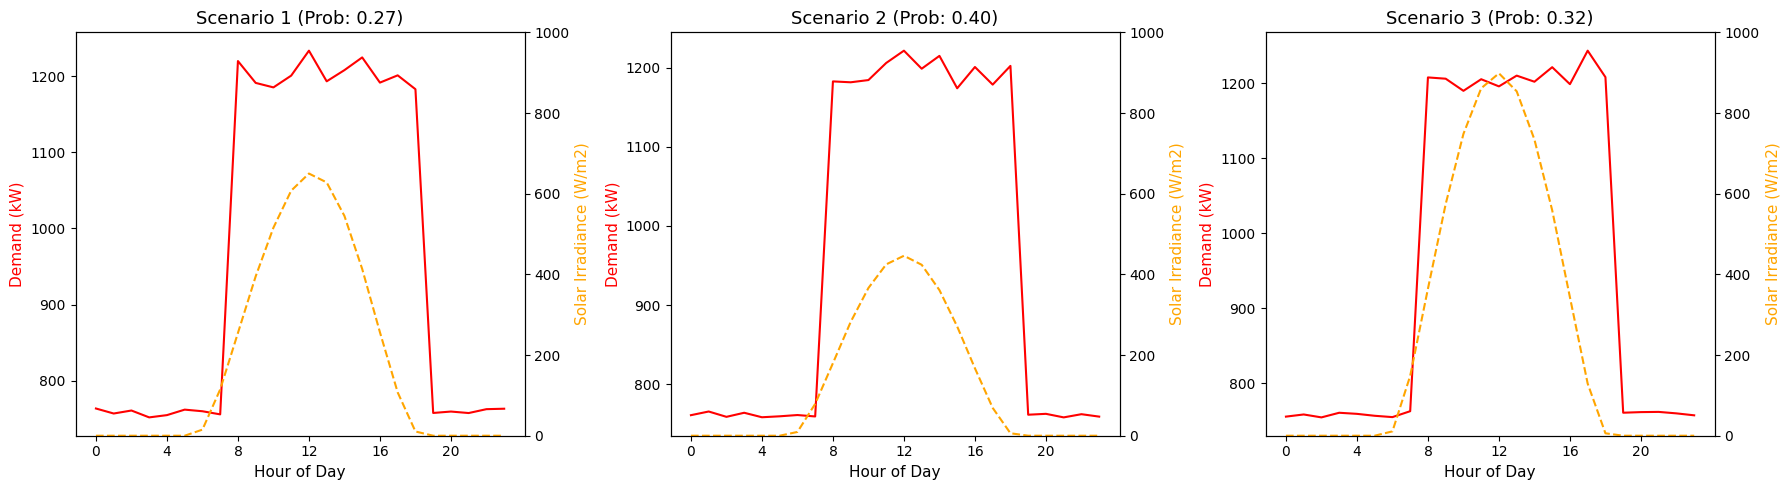

In [137]:
# ==========================================
# Visualization: Plotting the Representative Days
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for i in range(3):
    omega_key = f"omega_{i+1}"
    ax = axes[i]

    # Plot Demand on primary Y-axis
    ax.plot(omega_scenarios[omega_key]['demand_profile'], color='red', label='Demand (kW)')
    ax.set_ylabel('Demand (kW)', color='red')
    ax.set_title(f"Scenario {i+1} (Prob: {omega_scenarios[omega_key]['probability']:.2f})")
    ax.set_xlabel('Hour of Day')
    ax.set_xticks(range(0, 24, 4))

    # Plot Solar on secondary Y-axis
    ax2 = ax.twinx()
    ax2.plot(omega_scenarios[omega_key]['solar_profile'], color='orange', label='Solar (W/m2)', linestyle='--')
    ax2.set_ylabel('Solar Irradiance (W/m2)', color='orange')
    ax2.set_ylim(0, 1000)

plt.tight_layout()
plt.show()

#### 2.2.7 Python Code

In [138]:
import pyomo.environ as pyo

def solve_stochastic_microgrid(omega_scenarios):
    print("Building Two-Stage Stochastic MILP Model...")
    m = pyo.ConcreteModel()

    # -------------------------------------------------------------
    # 1. Sets and Indices
    # -------------------------------------------------------------
    # T = 24 hours (0 to 23)
    m.T = pyo.RangeSet(0, 23)

    # Omega = Scenarios from K-Means (e.g., 'omega_1', 'omega_2', 'omega_3')
    m.Omega = pyo.Set(initialize=list(omega_scenarios.keys()))

    # -------------------------------------------------------------
    # 2. Parameters
    # -------------------------------------------------------------
    # Economic Parameters (Assumed Annualized Costs)
    # Solar: ~30,000 THB/kW over 20 years -> ~1,500 THB/kW/year
    # Battery: ~15,000 THB/kWh over 10 years -> ~1,500 THB/kWh/year
    annual_capex_solar = 1500.0
    annual_capex_batt = 1500.0
    efficiency = 0.95
    M = 10000.0 # Big-M constant for logical constraints

    # 24-Hour PEA TOU Tariff Profile (THB)
    # Off-Peak: 0-8 and 22-23 (2.6037), On-Peak: 9-21 (4.1839)
    pea_price = {t: 4.1839 if 9 <= t < 22 else 2.6037 for t in range(24)}

    # -------------------------------------------------------------
    # 3. Decision Variables
    # -------------------------------------------------------------
    # Stage 1: Investment (Independent of Omega)
    m.I_solar = pyo.Var(within=pyo.NonNegativeIntegers) # Number of 50kW blocks
    m.S_solar = pyo.Var(within=pyo.NonNegativeReals)    # Total Solar Capacity
    m.S_batt = pyo.Var(within=pyo.NonNegativeReals)     # Total Battery Capacity

    # Stage 2: Operational Dispatch (Dependent on T and Omega)
    m.P_grid = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.P_solar_use = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)

    # Binary variable for mutually exclusive battery operation
    m.u = pyo.Var(m.T, m.Omega, within=pyo.Binary)

    # -------------------------------------------------------------
    # 4. Constraints
    # -------------------------------------------------------------
    # Discrete Investment Sizing
    def discrete_solar_rule(m):
        return m.S_solar == 50 * m.I_solar
    m.c_discrete = pyo.Constraint(rule=discrete_solar_rule)

    # Scenario-Dependent Energy Balance
    def energy_balance_rule(m, t, w):
        demand = omega_scenarios[w]['demand_profile'][t]
        return m.P_grid[t, w] + m.P_solar_use[t, w] + m.P_dis[t, w] == demand + m.P_ch[t, w]
    m.c_energy = pyo.Constraint(m.T, m.Omega, rule=energy_balance_rule)

    # Scenario-Dependent Solar Generation Limit
    def solar_limit_rule(m, t, w):
        # Convert W/m2 to yield factor (kW output per kW installed)
        solar_yield = max(0, omega_scenarios[w]['solar_profile'][t]) / 1000.0
        return m.P_solar_use[t, w] + m.P_ch[t, w] <= m.S_solar * solar_yield
    m.c_solar = pyo.Constraint(m.T, m.Omega, rule=solar_limit_rule)

    # SOC Dynamics
    def soc_rule(m, t, w):
        if t == 0:
            # Assume starting empty for simplicity, or link to end of day
            return m.SOC[t, w] == (m.P_ch[t, w] * efficiency) - (m.P_dis[t, w] / efficiency)
        else:
            return m.SOC[t, w] == m.SOC[t-1, w] + (m.P_ch[t, w] * efficiency) - (m.P_dis[t, w] / efficiency)
    m.c_soc = pyo.Constraint(m.T, m.Omega, rule=soc_rule)

    # Maximum Battery Capacity Limit
    def soc_cap_rule(m, t, w):
        return m.SOC[t, w] <= m.S_batt
    m.c_soc_cap = pyo.Constraint(m.T, m.Omega, rule=soc_cap_rule)

    # Mutually Exclusive Battery Operations (Big-M Logic)
    def charge_mutex_rule(m, t, w):
        return m.P_ch[t, w] <= M * m.u[t, w]
    m.c_ch_mutex = pyo.Constraint(m.T, m.Omega, rule=charge_mutex_rule)

    def discharge_mutex_rule(m, t, w):
        return m.P_dis[t, w] <= M * (1 - m.u[t, w])
    m.c_dis_mutex = pyo.Constraint(m.T, m.Omega, rule=discharge_mutex_rule)

    # -------------------------------------------------------------
    # 5. Objective Function (Minimize Expected Total Annual Cost)
    # -------------------------------------------------------------
    def objective_rule(m):
        capex = (m.S_solar * annual_capex_solar) + (m.S_batt * annual_capex_batt)

        # Calculate Expected Daily OPEX
        expected_daily_opex = 0
        for w in m.Omega:
            prob = omega_scenarios[w]['probability']
            # Sum of hourly grid costs for this scenario
            scenario_cost = sum(m.P_grid[t, w] * pea_price[t] for t in m.T)
            expected_daily_opex += prob * scenario_cost

        # Annualize OPEX by multiplying by 365 days
        annual_opex = expected_daily_opex * 365.0

        return capex + annual_opex

    m.Obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    # -------------------------------------------------------------
    # 6. Solve the Model
    # -------------------------------------------------------------
    print("Solving Stochastic MILP with GLPK...")
    solver = pyo.SolverFactory('glpk')
    results = solver.solve(m, tee=False)

    print("-" * 40)
    print(f"Solver Status: {results.solver.status}")
    print(f"Optimal Solar Capacity: {pyo.value(m.S_solar):.2f} kW ({pyo.value(m.I_solar)} blocks)")
    print(f"Optimal Battery Capacity: {pyo.value(m.S_batt):.2f} kWh")
    print(f"Total Expected Annual Cost: {pyo.value(m.Obj):,.2f} THB")

    return m

# Execute the model using the scenarios generated from K-Means
m_stochastic = solve_stochastic_microgrid(omega_scenarios)

Building Two-Stage Stochastic MILP Model...
Solving Stochastic MILP with GLPK...
----------------------------------------
Solver Status: ok
Optimal Solar Capacity: 3250.00 kW (65.0 blocks)
Optimal Battery Capacity: 0.00 kWh
Total Expected Annual Cost: 19,645,652.78 THB


=== Optimal Investment Decisions (Stage 1) ===
Total Expected Annual Cost: 19,645,652.78 THB
Installed Solar Capacity: 3,250.00 kW
Installed Battery Capacity: 0.00 kWh



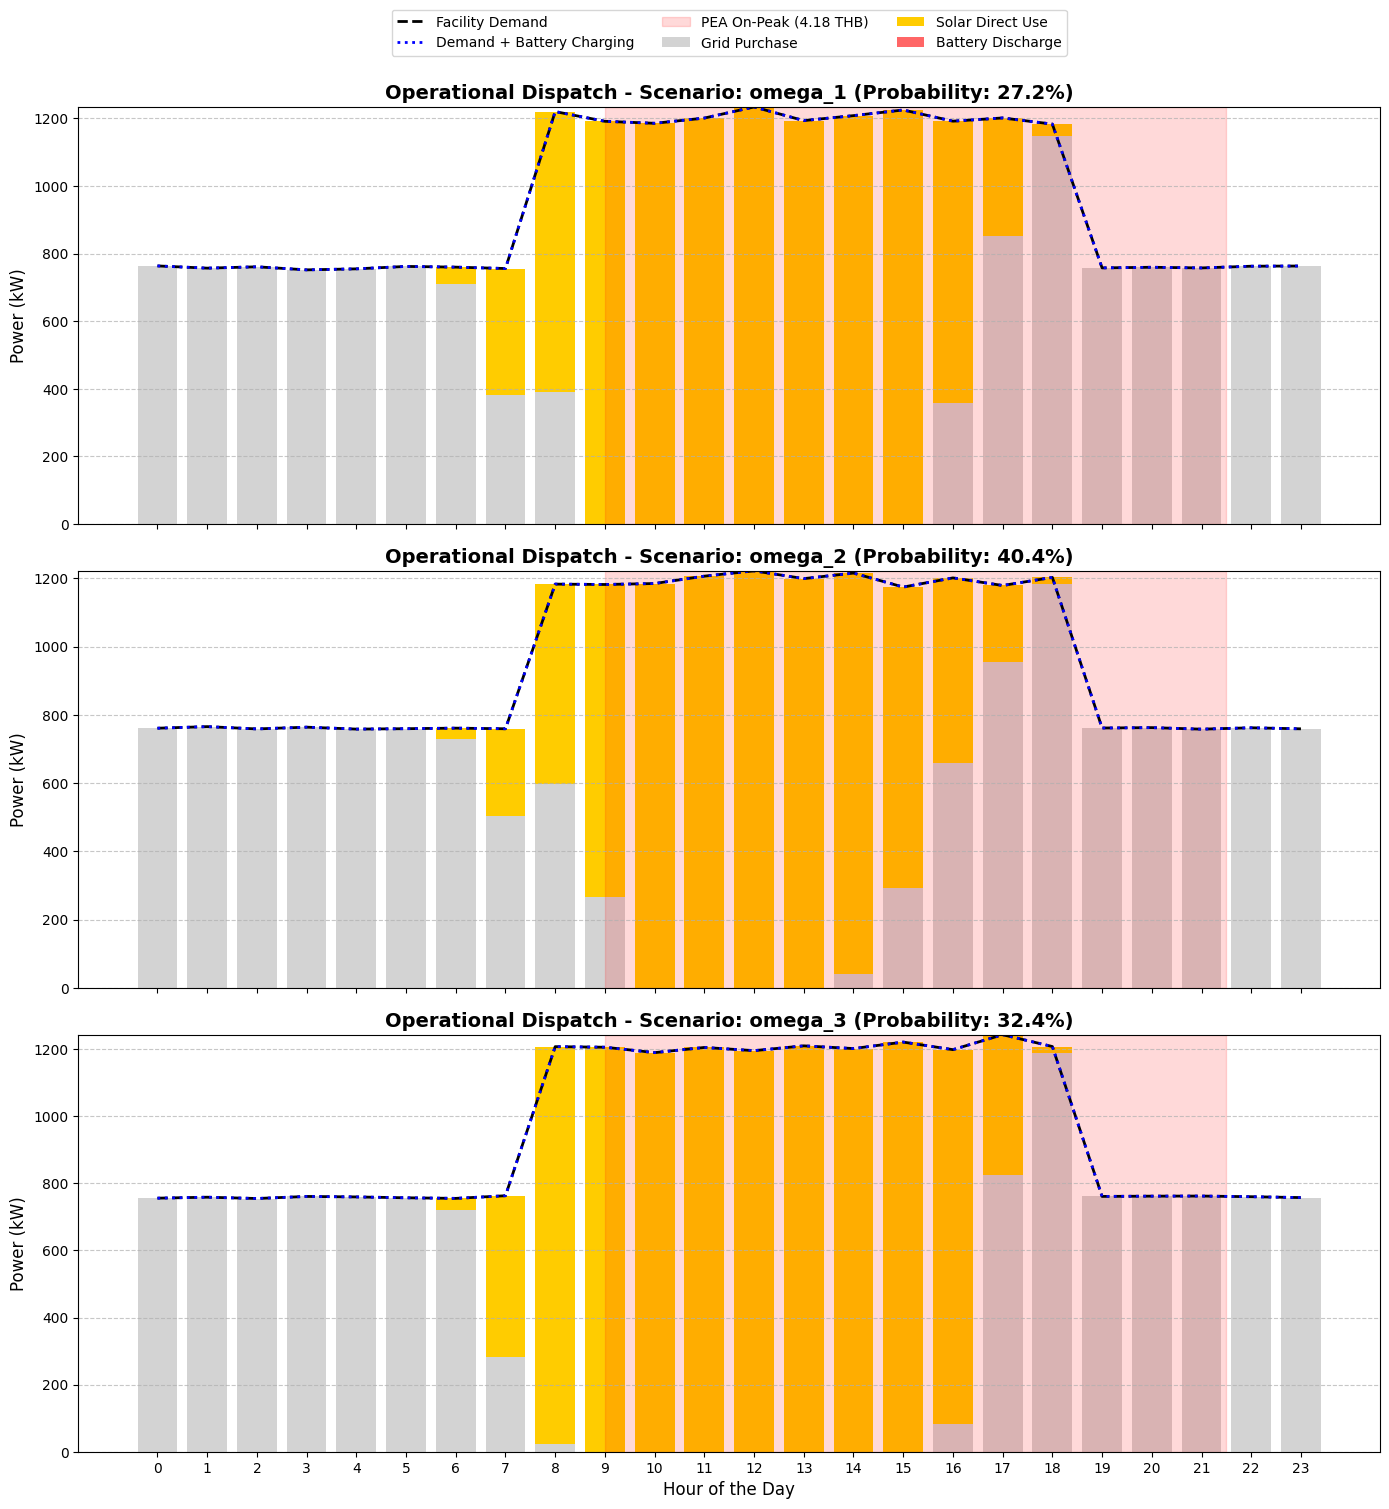

=== State of Charge (SOC) Snapshot ===


,omega_1,omega_2,omega_3
Hour,,,
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0
5,0.0,0.0,0.0
6,0.0,0.0,0.0
7,0.0,0.0,0.0
8,0.0,0.0,0.0


In [139]:
def extract_and_plot_results(m, scenarios_data):
    print("=== Optimal Investment Decisions (Stage 1) ===")
    print(f"Total Expected Annual Cost: {pyo.value(m.Obj):,.2f} THB")
    print(f"Installed Solar Capacity: {pyo.value(m.S_solar):,.2f} kW")
    print(f"Installed Battery Capacity: {pyo.value(m.S_batt):,.2f} kWh\n")

    # Define colors for the plot
    colors = {
        'Grid': '#d3d3d3',      # Light gray (Utility Grid)
        'Solar': '#ffcc00',       # Yellow (Solar PV)
        'Battery': '#ff6666'    # Light red (Battery Discharge)
    }

    # Create a figure with subplots corresponding to the number of scenarios
    scenarios_list = list(m.Omega)
    num_scenarios = len(scenarios_list)
    fig, axes = plt.subplots(num_scenarios, 1, figsize=(14, 5 * num_scenarios), sharex=True)

    # If there is only 1 scenario, 'axes' is not an array. Convert it to a list to avoid indexing errors.
    if num_scenarios == 1:
        axes = [axes]

    # Loop through and plot each scenario
    for idx, w in enumerate(scenarios_list):
        ax = axes[idx]

        # 1. Extract variable values into lists
        hours = [t for t in m.T]
        p_grid = [pyo.value(m.P_grid[t, w]) for t in m.T]
        p_solar = [pyo.value(m.P_solar_use[t, w]) for t in m.T]
        p_dis = [pyo.value(m.P_dis[t, w]) for t in m.T]
        p_ch = [pyo.value(m.P_ch[t, w]) for t in m.T]
        soc = [pyo.value(m.SOC[t, w]) for t in m.T]
        demand = scenarios_data[w]['demand_profile']

        # Calculate total required load (Facility Demand + Battery Charging Power)
        total_required = [demand[t] + p_ch[t] for t in hours]

        # 2. Plot Stacked Bar Chart for the supply side
        ax.bar(hours, p_grid, label='Grid Purchase', color=colors['Grid'], width=0.8)
        ax.bar(hours, p_solar, bottom=p_grid, label='Solar Direct Use', color=colors['Solar'], width=0.8)

        # Calculate the bottom base for the battery bars (stacked on top of grid and solar)
        bottom_for_batt = [p_grid[i] + p_solar[i] for i in range(len(hours))]
        ax.bar(hours, p_dis, bottom=bottom_for_batt, label='Battery Discharge', color=colors['Battery'], width=0.8)

        # 3. Plot the Demand and Total Required lines
        ax.plot(hours, demand, color='black', linewidth=2, linestyle='--', label='Facility Demand')
        ax.plot(hours, total_required, color='blue', linewidth=2, linestyle=':', label='Demand + Battery Charging')

        # 4. Highlight the On-Peak period (09:00 - 22:00) with a light red background
        ax.axvspan(9, 21.5, color='red', alpha=0.15, label='PEA On-Peak (4.18 THB)')

        # Format and decorate the plot
        prob = scenarios_data[w]['probability']
        ax.set_title(f"Operational Dispatch - Scenario: {w} (Probability: {prob*100:.1f}%)", fontsize=14, fontweight='bold')
        ax.set_ylabel("Power (kW)", fontsize=12)
        ax.set_xticks(hours)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        # Place the legend outside the plot to avoid overlapping data
        if idx == 0:
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=3, fontsize=10)

    axes[-1].set_xlabel("Hour of the Day", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Extract and display the State of Charge (SOC) as a table
    print("=== State of Charge (SOC) Snapshot ===")
    soc_df = pd.DataFrame({w: [pyo.value(m.SOC[t, w]) for t in m.T] for w in m.Omega})
    soc_df.index.name = 'Hour'
    display(soc_df.head(10).round(2))

# Execute the function by passing the solved model and the scenarios data
extract_and_plot_results(m_stochastic, omega_scenarios)

### **Model 3: Comprehensive Enterprise Microgrid Model**

**Background & Assumptions:**
This advanced formulation represents a highly complex, real-world enterprise energy system. It builds upon the Two-Stage Stochastic MILP by integrating three advanced Operations Research domains simultaneously:
1. **Risk Management (CVaR):** Instead of merely minimizing the expected average cost, the model balances expected costs against the **Conditional Value at Risk (CVaR)** to protect the facility from extreme worst-case scenarios (e.g., consecutive days of severe weather).
2. **Unit Commitment (Diesel Generator):** Introduces a backup Diesel Generator (DG) subject to strict operational physics, including start-up costs, minimum up/down times, and ramping limits, requiring complex binary logic.
3. **Peak Demand Charge:** Incorporates the facility's maximum monthly grid power draw ($P^{peak}$), penalizing massive sudden power surges and forcing the battery/generator to perform active "Peak Shaving."

## 3.1 Additional Sets and Indices
* $T$: Set of time periods ($t = 1, ..., 24$).
* $\Omega$: Set of representative scenarios ($\omega$).

## 3.2 Additional Parameters (Input Data)
**Risk Parameters (CVaR):**
* $\alpha$: Confidence level for assessing extreme risk (e.g., $0.95$ for the worst 5% of cases).
* $\lambda$: Risk-aversion weighting factor ($0 \leq \lambda \leq 1$). If $\lambda = 0$, the model is risk-neutral. If $\lambda = 1$, the model strictly minimizes extreme losses.

**Diesel Generator (DG) Parameters:**
* $P^{dg}_{min}, P^{dg}_{max}$: Minimum and maximum operational power output of the DG (kW).
* $C^{dg}_{op}$: Operational fuel cost of the DG (THB/kWh).
* $C^{dg}_{start}$: Fixed cost incurred every time the DG is started (THB).
* $RU, RD$: Maximum Ramp-Up and Ramp-Down rates of the DG (kW/hour).
* $UT, DT$: Minimum Up-Time and Minimum Down-Time (hours) to prevent mechanical wear.

**Demand Charge Parameter:**
* $C^{demand}$: Monthly peak demand penalty rate (THB/kW).

## 3.3 Expanded Decision Variables
**Investment Variables (Stage 1):**
* $S_{solar}, S_{batt} \geq 0$: Installed capacities of Solar and Battery.

**Operational Variables (Stage 2 - Scenario Dependent):**
* $P^{grid}_{t,\omega}, P^{solar\_use}_{t,\omega}, P^{ch}_{t,\omega}, P^{dis}_{t,\omega}, SOC_{t,\omega} \geq 0$: Standard energy dispatch variables.
* $P^{dg}_{t,\omega} \geq 0$: Power generated by the Diesel Generator at time $t$, scenario $\omega$.
* $u^{dg}_{t,\omega} \in \{0,1\}$: Binary status of the DG (1 if running, 0 if off).
* $v^{dg}_{t,\omega} \in \{0,1\}$: Binary start-up indicator (1 if DG is turned on at time $t$).
* $w^{dg}_{t,\omega} \in \{0,1\}$: Binary shut-down indicator (1 if DG is turned off at time $t$).
* $P^{peak}_\omega \geq 0$: The maximum grid power purchased in scenario $\omega$ (for Demand Charge calculation).

**Risk Variables (CVaR):**
* $\zeta \in \mathbb{R}$: The Value at Risk (VaR), representing the cost threshold of the worst $(1-\alpha)$ scenarios.
* $z_\omega \geq 0$: Auxiliary variable representing the shortfall (cost exceeding VaR) in scenario $\omega$.

## 3.4 Objective Function
**Goal:** Minimize the weighted sum of the Expected Total Cost and the Conditional Value at Risk (CVaR).

Let the Total Cost in a specific scenario $\omega$ be defined as $TC_\omega$:
$$TC_\omega = C^{solar}_{capex}S_{solar} + C^{batt}_{capex}S_{batt} + \sum_{t \in T} \left( C^{grid}_t P^{grid}_{t,\omega} + C^{dg}_{op} P^{dg}_{t,\omega} + C^{dg}_{start} v^{dg}_{t,\omega} \right) + C^{demand} P^{peak}_\omega$$

The final Objective Function balances expectation and risk:
$$\min Z = (1 - \lambda) \left[ \sum_{\omega \in \Omega} \pi_\omega TC_\omega \right] + \lambda \left[ \zeta + \frac{1}{1-\alpha} \sum_{\omega \in \Omega} \pi_\omega z_\omega \right]$$

## 3.5 Constraints

**1. System Energy Balance (Updated with DG):**
$$P^{grid}_{t,\omega} + P^{solar\_use}_{t,\omega} + P^{dis}_{t,\omega} + P^{dg}_{t,\omega} = D_{t,\omega} + P^{ch}_{t,\omega} \quad \forall t, \forall \omega$$

**2. Demand Charge (Peak Shaving Limit):**
The peak demand is defined as the highest grid power draw across the entire period.
$$P^{grid}_{t,\omega} \leq P^{peak}_\omega \quad \forall t \in T, \forall \omega \in \Omega$$

**3. Solar & Battery Physical Limits (From Model 2):**
$$P^{solar\_use}_{t,\omega} + P^{ch}_{t,\omega} \leq S_{solar} \times \left(\frac{GHI_{t,\omega}}{1000}\right) \quad \forall t, \forall \omega$$
$$SOC_{t,\omega} = SOC_{t-1,\omega} + (P^{ch}_{t,\omega} \cdot \eta) - \left( \frac{P^{dis}_{t,\omega}}{\eta} \right) \quad \forall t, \forall \omega$$
$$SOC_{t,\omega} \leq S_{batt} \quad \forall t, \forall \omega$$
$$P^{ch}_{t,\omega} \leq M \cdot u^{batt}_{t,\omega} \quad \text{and} \quad P^{dis}_{t,\omega} \leq M \cdot (1 - u^{batt}_{t,\omega}) \quad \forall t, \forall \omega$$

**4. Diesel Generator Unit Commitment (Binary Logic):**

*A. Logical Status Relationship:*
$$u^{dg}_{t,\omega} - u^{dg}_{t-1,\omega} = v^{dg}_{t,\omega} - w^{dg}_{t,\omega} \quad \forall t, \forall \omega$$
*B. Minimum and Maximum Generation Limits:*
$$P^{dg}_{min} \cdot u^{dg}_{t,\omega} \leq P^{dg}_{t,\omega} \leq P^{dg}_{max} \cdot u^{dg}_{t,\omega} \quad \forall t, \forall \omega$$
*C. Ramping Constraints (Up and Down):*
$$P^{dg}_{t,\omega} - P^{dg}_{t-1,\omega} \leq RU \cdot u^{dg}_{t-1,\omega} + P^{dg}_{min} \cdot v^{dg}_{t,\omega} \quad \forall t, \forall \omega$$
$$P^{dg}_{t-1,\omega} - P^{dg}_{t,\omega} \leq RD \cdot u^{dg}_{t,\omega} + P^{dg}_{min} \cdot w^{dg}_{t,\omega} \quad \forall t, \forall \omega$$
*D. Minimum Up-Time (UT) and Down-Time (DT):*
$$\sum_{\tau = t - UT + 1}^{t} v^{dg}_{\tau,\omega} \leq u^{dg}_{t,\omega} \quad \forall t \geq UT, \forall \omega$$
$$\sum_{\tau = t - DT + 1}^{t} w^{dg}_{\tau,\omega} \leq 1 - u^{dg}_{t,\omega} \quad \forall t \geq DT, \forall \omega$$

**5. CVaR Auxiliary Constraints:**
To calculate the tail risk, the shortfall variable $z_\omega$ measures how much a scenario's cost exceeds the Value at Risk ($\zeta$).
$$z_\omega \geq TC_\omega - \zeta \quad \forall \omega \in \Omega$$
$$z_\omega \geq 0 \quad \forall \omega \in \Omega$$

---

#### 2.3.1 Python Code

In [140]:
import pyomo.environ as pyo
import pandas as pd
import matplotlib.pyplot as plt

def solve_enterprise_microgrid(omega_scenarios):
    print("Building Model 3: Enterprise Microgrid (CVaR + DG + Peak Demand)...")
    m = pyo.ConcreteModel()

    # -------------------------------------------------------------
    # 1. Sets
    # -------------------------------------------------------------
    m.T = pyo.RangeSet(0, 23)
    m.Omega = pyo.Set(initialize=list(omega_scenarios.keys()))

    # -------------------------------------------------------------
    # 2. Parameters (With Additional Data for Model 3)
    # -------------------------------------------------------------
    # Investment Costs (Annualized)
    annual_capex_solar = 1500.0
    annual_capex_batt = 1500.0

    # PEA TOU & Demand Charge
    pea_price = {t: 4.1839 if 9 <= t < 22 else 2.6037 for t in range(24)}
    annual_demand_charge = 132.0 * 12 # 132 THB/kW/month * 12 months

    # Diesel Generator (DG) Parameters
    P_dg_min = 50.0      # Minimum stable running limit (kW)
    P_dg_max = 500.0     # Maximum DG capacity (kW)
    C_dg_op = 6.0        # High operational cost (Fuel THB/kWh)
    C_dg_start = 200.0   # Cost per engine start-up (THB)

    # Risk Parameters (CVaR) for Sensitivity Analysis
    alpha = 0.95         # Look at the worst 5% of cases
    lambda_risk = 0.5    # 0 = Risk Neutral, 1 = Extremely Risk Averse

    M = 10000.0          # Big-M Constant
    efficiency = 0.95

    # -------------------------------------------------------------
    # 3. Decision Variables
    # -------------------------------------------------------------
    # Stage 1: Capacities
    m.S_solar = pyo.Var(within=pyo.NonNegativeReals)
    m.S_batt = pyo.Var(within=pyo.NonNegativeReals)

    # Stage 2: Dispatch
    m.P_grid = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.P_solar_use = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)

    # Stage 2: Diesel Generator & Peak Demand
    m.P_dg = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.u_dg = pyo.Var(m.T, m.Omega, within=pyo.Binary) # On/Off status
    m.v_dg = pyo.Var(m.T, m.Omega, within=pyo.Binary) # Start-up status
    m.w_dg = pyo.Var(m.T, m.Omega, within=pyo.Binary) # Shut-down status

    m.P_peak = pyo.Var(m.Omega, within=pyo.NonNegativeReals)
    m.u_batt = pyo.Var(m.T, m.Omega, within=pyo.Binary) # Battery mutex

    # Stage 2: CVaR Variables
    m.zeta = pyo.Var(within=pyo.Reals) # Value at Risk (VaR)
    m.z = pyo.Var(m.Omega, within=pyo.NonNegativeReals) # Shortfall

    # -------------------------------------------------------------
    # 4. Constraints
    # -------------------------------------------------------------
    # 4.1 System Energy Balance (Now includes DG)
    def energy_balance_rule(m, t, w):
        demand = omega_scenarios[w]['demand_profile'][t]
        return m.P_grid[t, w] + m.P_solar_use[t, w] + m.P_dis[t, w] + m.P_dg[t, w] == demand + m.P_ch[t, w]
    m.c_energy = pyo.Constraint(m.T, m.Omega, rule=energy_balance_rule)

    # 4.2 Peak Demand Limit
    def peak_demand_rule(m, t, w):
        return m.P_grid[t, w] <= m.P_peak[w]
    m.c_peak = pyo.Constraint(m.T, m.Omega, rule=peak_demand_rule)

    # 4.3 Solar & Battery Dynamics
    def solar_limit_rule(m, t, w):
        solar_yield = max(0, omega_scenarios[w]['solar_profile'][t]) / 1000.0
        return m.P_solar_use[t, w] + m.P_ch[t, w] <= m.S_solar * solar_yield
    m.c_solar = pyo.Constraint(m.T, m.Omega, rule=solar_limit_rule)

    def soc_rule(m, t, w):
        if t == 0:
            return m.SOC[t, w] == (m.P_ch[t, w] * efficiency) - (m.P_dis[t, w] / efficiency)
        return m.SOC[t, w] == m.SOC[t-1, w] + (m.P_ch[t, w] * efficiency) - (m.P_dis[t, w] / efficiency)
    m.c_soc = pyo.Constraint(m.T, m.Omega, rule=soc_rule)

    def soc_cap_rule(m, t, w):
        return m.SOC[t, w] <= m.S_batt
    m.c_soc_cap = pyo.Constraint(m.T, m.Omega, rule=soc_cap_rule)

    def batt_mutex_ch_rule(m, t, w): return m.P_ch[t, w] <= M * m.u_batt[t, w]
    def batt_mutex_dis_rule(m, t, w): return m.P_dis[t, w] <= M * (1 - m.u_batt[t, w])
    m.c_batt_ch = pyo.Constraint(m.T, m.Omega, rule=batt_mutex_ch_rule)
    m.c_batt_dis = pyo.Constraint(m.T, m.Omega, rule=batt_mutex_dis_rule)

    # 4.4 Diesel Generator Unit Commitment Logic
    def dg_status_rule(m, t, w):
        if t == 0:
            return m.u_dg[t, w] == m.v_dg[t, w] - m.w_dg[t, w]
        return m.u_dg[t, w] - m.u_dg[t-1, w] == m.v_dg[t, w] - m.w_dg[t, w]
    m.c_dg_status = pyo.Constraint(m.T, m.Omega, rule=dg_status_rule)

    def dg_min_rule(m, t, w): return m.P_dg[t, w] >= P_dg_min * m.u_dg[t, w]
    def dg_max_rule(m, t, w): return m.P_dg[t, w] <= P_dg_max * m.u_dg[t, w]
    m.c_dg_min = pyo.Constraint(m.T, m.Omega, rule=dg_min_rule)
    m.c_dg_max = pyo.Constraint(m.T, m.Omega, rule=dg_max_rule)

    # 4.5 CVaR Constraints
    def cost_scenario_rule(m, w):
        capex = (m.S_solar * annual_capex_solar) + (m.S_batt * annual_capex_batt)
        opex_grid = sum(m.P_grid[t, w] * pea_price[t] for t in m.T) * 365.0
        opex_dg = sum((m.P_dg[t, w] * C_dg_op) + (m.v_dg[t, w] * C_dg_start) for t in m.T) * 365.0
        demand_cost = m.P_peak[w] * annual_demand_charge

        # Total cost for this specific scenario
        TC_w = capex + opex_grid + opex_dg + demand_cost
        return m.z[w] >= TC_w - m.zeta
    m.c_cvar = pyo.Constraint(m.Omega, rule=cost_scenario_rule)

    # -------------------------------------------------------------
    # 5. Objective Function (Minimize Expected Cost + CVaR)
    # -------------------------------------------------------------
    def objective_rule(m):
        # Expected Total Cost
        Expected_TC = 0
        for w in m.Omega:
            prob = omega_scenarios[w]['probability']
            capex = (m.S_solar * annual_capex_solar) + (m.S_batt * annual_capex_batt)
            opex = sum(m.P_grid[t,w]*pea_price[t] + m.P_dg[t,w]*C_dg_op + m.v_dg[t,w]*C_dg_start for t in m.T)*365.0
            demand = m.P_peak[w] * annual_demand_charge
            Expected_TC += prob * (capex + opex + demand)

        # CVaR Component
        CVaR = m.zeta + (1.0 / (1.0 - alpha)) * sum(omega_scenarios[w]['probability'] * m.z[w] for w in m.Omega)

        return (1 - lambda_risk) * Expected_TC + (lambda_risk) * CVaR

    m.Obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    # -------------------------------------------------------------
    # 6. Solve
    # -------------------------------------------------------------
    print("Solving Model... (This may take a moment due to integer variables)")
    solver = pyo.SolverFactory('glpk')
    # Set timeout for safety if Colab struggles
    solver.options['tmlim'] = 60
    results = solver.solve(m, tee=False)

    print("-" * 50)
    print(f"Status: {results.solver.status}")
    print(f"Optimal Solar Capacity: {pyo.value(m.S_solar):,.2f} kW")
    print(f"Optimal Battery Capacity: {pyo.value(m.S_batt):,.2f} kWh")
    print(f"Value at Risk (VaR): {pyo.value(m.zeta):,.2f} THB")
    print(f"Final Objective Value: {pyo.value(m.Obj):,.2f} THB")

    return m

# Run the model
m_enterprise = solve_enterprise_microgrid(omega_scenarios)

Building Model 3: Enterprise Microgrid (CVaR + DG + Peak Demand)...
Solving Model... (This may take a moment due to integer variables)
--------------------------------------------------
Status: ok
Optimal Solar Capacity: 3,615.15 kW
Optimal Battery Capacity: 609.46 kWh
Value at Risk (VaR): 22,258,724.79 THB
Final Objective Value: 21,632,566.99 THB


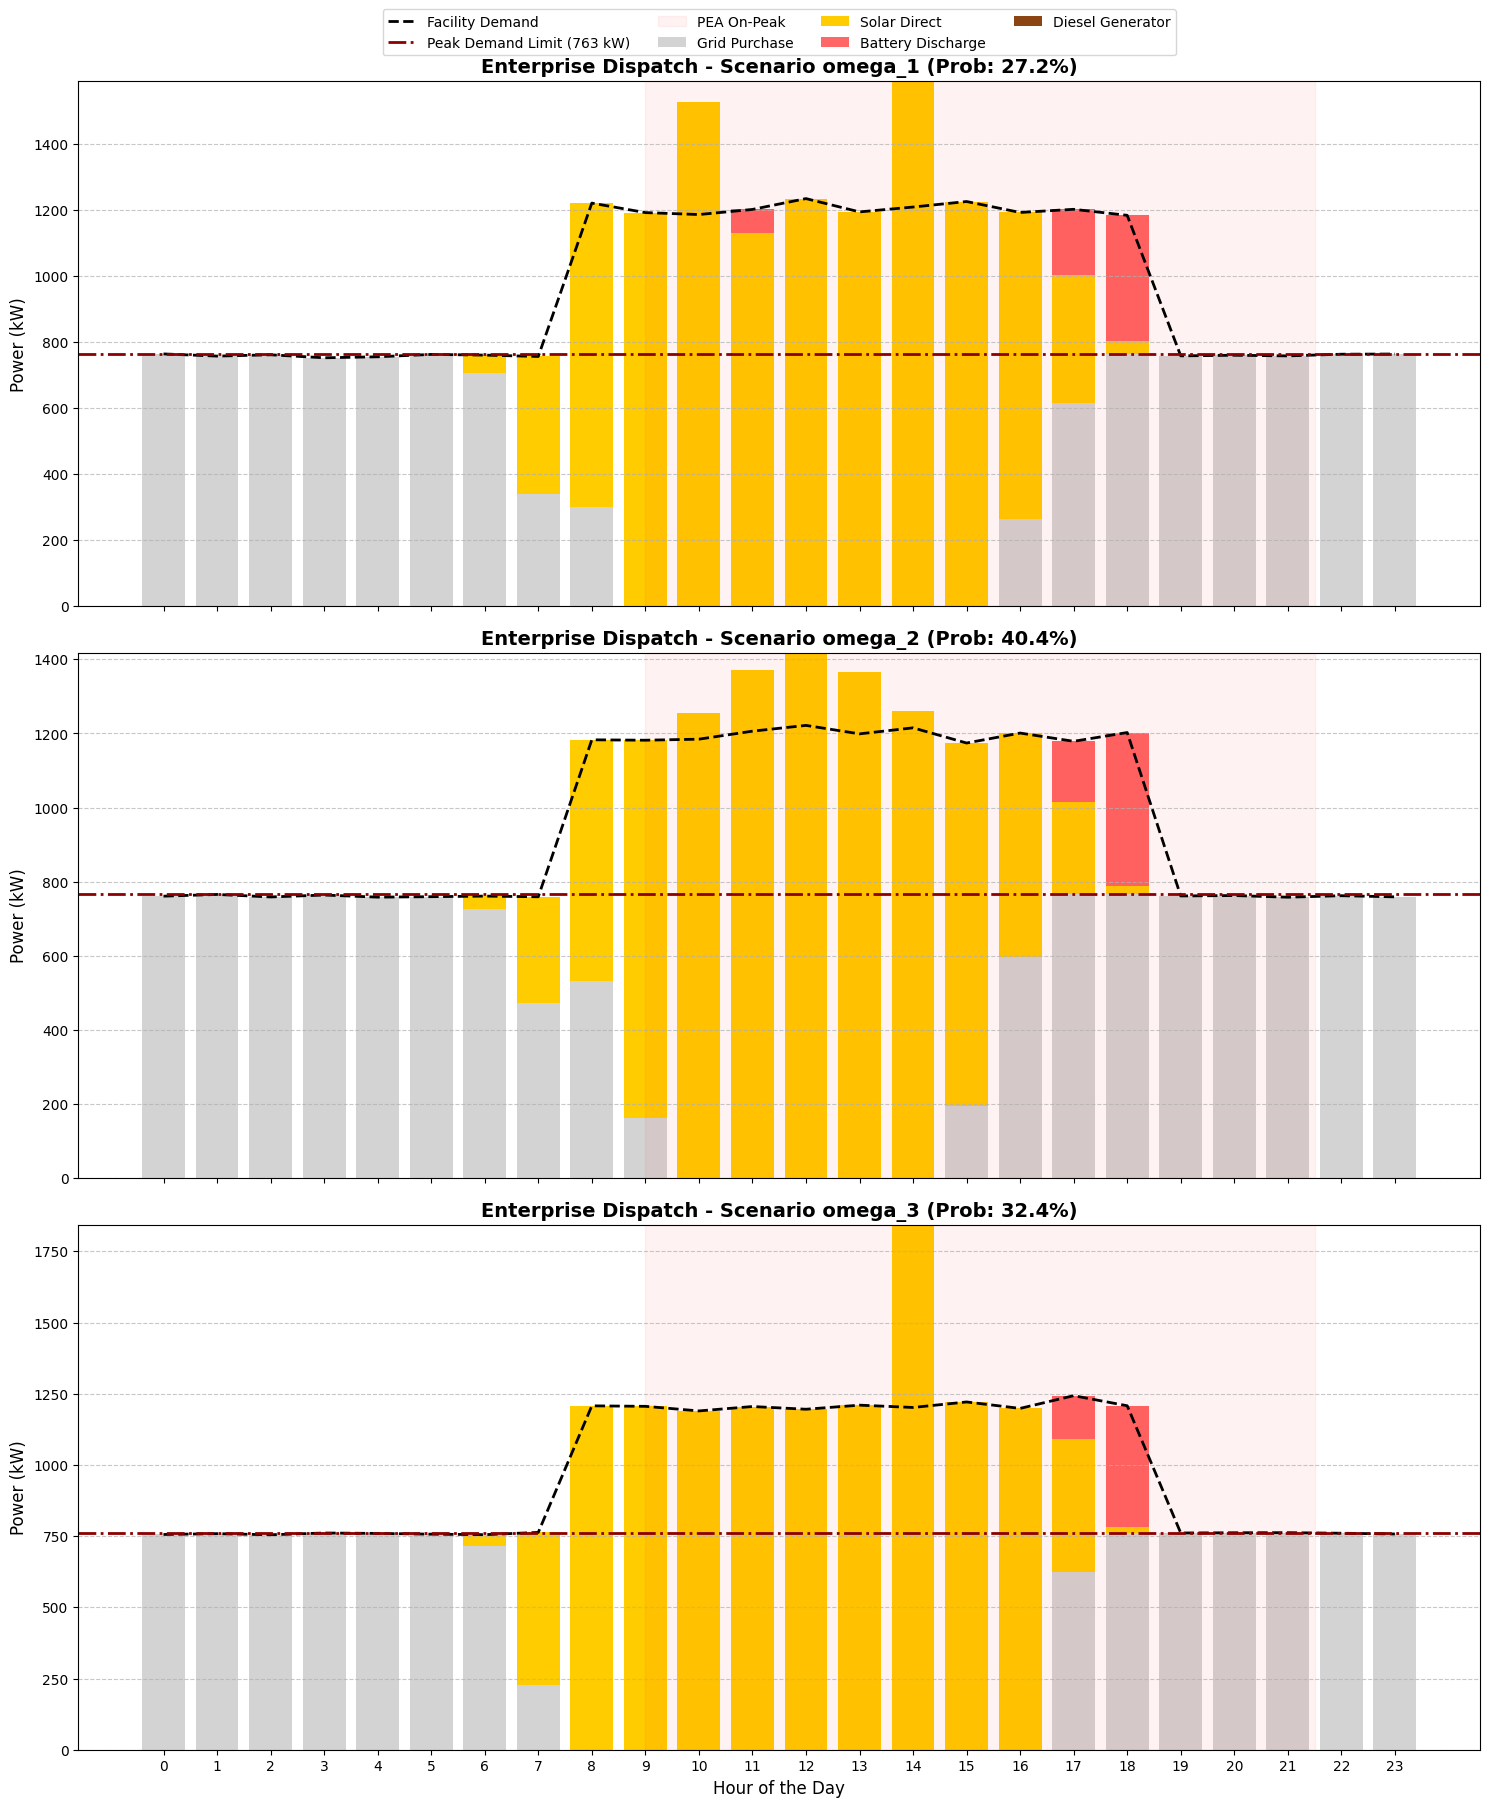

In [141]:
def extract_and_plot_enterprise(m, scenarios_data):
    colors = {
        'Grid': '#d3d3d3',
        'Solar': '#ffcc00',
        'Battery': '#ff6666',
        'Diesel': '#8b4513'     # Brown for Diesel Generator
    }

    scenarios_list = list(m.Omega)
    num_scenarios = len(scenarios_list)
    fig, axes = plt.subplots(num_scenarios, 1, figsize=(15, 6 * num_scenarios), sharex=True)
    if num_scenarios == 1: axes = [axes]

    for idx, w in enumerate(scenarios_list):
        ax = axes[idx]
        hours = [t for t in m.T]

        # Extract operational data
        p_grid = [pyo.value(m.P_grid[t, w]) for t in m.T]
        p_solar = [pyo.value(m.P_solar_use[t, w]) for t in m.T]
        p_dis = [pyo.value(m.P_dis[t, w]) for t in m.T]
        p_dg = [pyo.value(m.P_dg[t, w]) for t in m.T]
        p_ch = [pyo.value(m.P_ch[t, w]) for t in m.T]
        demand = scenarios_data[w]['demand_profile']
        peak_limit = pyo.value(m.P_peak[w])

        total_required = [demand[t] + p_ch[t] for t in hours]

        # Stacked Bars Strategy
        ax.bar(hours, p_grid, label='Grid Purchase', color=colors['Grid'], width=0.8)

        bottom1 = p_grid
        ax.bar(hours, p_solar, bottom=bottom1, label='Solar Direct', color=colors['Solar'], width=0.8)

        bottom2 = [bottom1[i] + p_solar[i] for i in range(len(hours))]
        ax.bar(hours, p_dis, bottom=bottom2, label='Battery Discharge', color=colors['Battery'], width=0.8)

        bottom3 = [bottom2[i] + p_dis[i] for i in range(len(hours))]
        ax.bar(hours, p_dg, bottom=bottom3, label='Diesel Generator', color=colors['Diesel'], width=0.8)

        # Plot Lines
        ax.plot(hours, demand, color='black', linewidth=2, linestyle='--', label='Facility Demand')
        ax.axhline(peak_limit, color='darkred', linewidth=2, linestyle='-.', label=f'Peak Demand Limit ({peak_limit:.0f} kW)')

        # Highlight On-Peak
        ax.axvspan(9, 21.5, color='red', alpha=0.05, label='PEA On-Peak')

        prob = scenarios_data[w]['probability']
        ax.set_title(f"Enterprise Dispatch - Scenario {w} (Prob: {prob*100:.1f}%)", fontsize=14, fontweight='bold')
        ax.set_ylabel("Power (kW)", fontsize=12)
        ax.set_xticks(hours)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        if idx == 0:
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=10)

    axes[-1].set_xlabel("Hour of the Day", fontsize=12)
    plt.tight_layout()
    plt.show()

extract_and_plot_enterprise(m_enterprise, omega_scenarios)

## 4. Model 4: Advanced Non-Linear and Lifecycle Microgrid Optimization

**Background & Assumptions:**
Building directly upon the Enterprise Microgrid Model (Model 3), Model 4 transitions from operational optimization to **Strategic & Lifecycle Optimization**. It addresses two critical economic realities that significantly impact the Net Present Value (NPV) of energy assets:
1. **Battery Degradation:** Lithium-ion batteries suffer microscopic damage with every charge/discharge cycle. Instead of treating battery usage as a "free" sunk cost, we introduce a marginal degradation cost ($C^{deg}$) per kWh discharged. This forces the solver to restrict battery cycles only to high-value peak-shaving periods.
2. **Tiered (Step-wise) Pricing:** Utility tariffs often scale with volume. We model this by splitting the total grid energy purchased into discrete tiers ($n \in N$), where energy consumed in higher tiers incurs a steeper penalty rate ($R_n$).

### 4.1 Parameter References & Academic Justifications
For a rigorous Master's level thesis, the input parameters should be grounded in accepted industry benchmarks.

* **Solar PV CAPEX ($C^{solar}_{capex}$):** Assumed at approximately 22,000 - 30,000 THB/kW.
  * *Reference:* International Renewable Energy Agency (IRENA), "Renewable Power Generation Costs in 2022".
* **Li-ion Battery CAPEX ($C^{batt}_{capex}$):** Assumed at approximately 12,000 - 18,000 THB/kWh.
  * *Reference:* National Renewable Energy Laboratory (NREL), "2023 Annual Technology Baseline (ATB) for Utility-Scale Battery Storage".
* **Battery Degradation Cost ($C^{deg}$):** Estimated at 2.50 - 4.50 THB per kWh throughput, calculated based on replacement cost divided by expected cycle life and Depth of Discharge (DoD).
  * *Reference:* Lazard, "Levelized Cost of Storage Analysis (LCOS Version 9.0, 2023)".
* **Electricity Tariffs:** Modeled after the Provincial Electricity Authority (PEA) of Thailand.
  * *Reference:* PEA Official Tariff Announcements (Type 4: Large General Service, Time of Use).

### 4.2 Additional Sets and Indices
* $N$: Set of electricity pricing tiers ($n = 1, 2, ..., N$).

### 4.3 Additional Parameters (Input Data)
* $C^{deg}$: Marginal battery degradation cost (THB/kWh throughput).
* $\Delta L_n$: Maximum allowable energy consumption limit within a specific pricing tier $n$ (kWh).
* $R_n$: Electricity rate applied to energy consumed in tier $n$ (THB/kWh). To maintain mathematical convexity, prices strictly increase: $R_1 < R_2 < ... < R_N$.

### 4.4 Expanded Decision Variables
* $E^{grid}_{\omega, n} \geq 0$: Energy purchased from the grid allocated to tier $n$ under scenario $\omega$ (kWh).

### 4.5 Updated Objective Function
**Goal:** Minimize the Risk-Adjusted Total Lifecycle Cost, integrating battery decay and tiered utility purchasing.

The Total Cost for a specific scenario $\omega$ ($TC_\omega$) is redefined as:
$$TC_\omega = C^{solar}_{capex}S_{solar} + C^{batt}_{capex}S_{batt} + \left( \sum_{n \in N} R_n E^{grid}_{\omega, n} \right) + \sum_{t \in T} \left( C^{dg}_{op} P^{dg}_{t,\omega} + C^{dg}_{start} v^{dg}_{t,\omega} + C^{deg} P^{dis}_{t,\omega} \right) + C^{demand} P^{peak}_\omega$$

The overarching objective balances the Expected Cost and the Conditional Value at Risk (CVaR):
$$\min Z = (1 - \lambda) \left[ \sum_{\omega \in \Omega} \pi_\omega TC_\omega \right] + \lambda \left[ \zeta + \frac{1}{1-\alpha} \sum_{\omega \in \Omega} \pi_\omega z_\omega \right]$$

### 4.6 Updated Constraints
All constraints from Model 3 (Energy Balance, Peak Demand limits, Diesel Generator Unit Commitment, Solar Limits, and CVaR auxiliary equations) remain active. We introduce the following piecewise linear constraints:

**1. Tiered Pricing Allocation (Piecewise Summation):**
The total grid power drawn across all hours in a scenario must equal the sum of the energy allocated to the distinct pricing tiers.
$$\sum_{t \in T} P^{grid}_{t,\omega} = \sum_{n \in N} E^{grid}_{\omega, n} \quad \forall \omega \in \Omega$$

**2. Tier Capacity Limits:**
The energy allocated to each tier cannot exceed that tier's predefined volume capacity limit ($\Delta L_n$). Because the objective is to minimize cost and the rates strictly increase ($R_1 < R_2$), the MILP solver will naturally exhaust the capacity of Tier 1 before allocating any energy to Tier 2.
$$E^{grid}_{\omega, n} \leq \Delta L_n \quad \forall \omega \in \Omega, \forall n \in N$$

---

#### 2.4.1 Scenario Generation & Data Initialization

This block ensures that the stochastic scenarios ($\omega_1, \omega_2, \omega_3$) are available in the memory.

In [156]:
# Block 1: Setup & Data Validation
import numpy as np
import pandas as pd

# 1. Install GLPK Solver (Critical for Colab)
!apt-get install -y -qq glpk-utils

# 2. Check omega_scenarios status
if 'omega_scenarios' not in locals() and 'omega_scenarios' not in globals():
    print("❌ Error: 'omega_scenarios' not found. Please run the Data Construction cells.")
else:
    # Verify data integrity
    sample_key = list(omega_scenarios.keys())[0]
    if len(omega_scenarios[sample_key]['demand_profile']) == 24:
        print(f"✅ Ready: Scenarios detected ({len(omega_scenarios)} clusters).")
    else:
        print("❌ Error: Data profiles are incomplete. Re-run scenario generation.")

✅ Ready: Scenarios detected (3 clusters).


In [159]:
pd.DataFrame(omega_scenarios)

,omega_1,omega_2,omega_3
probability,0.272,0.4038,0.3242
days_count,99,147,118
demand_profile,"[763.4075757575758, 756.8215151515152, 760.759...","[760.6985034013605, 765.3454421768708, 758.603...","[755.855, 758.7127966101696, 754.8304237288136..."
solar_profile,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.082444444444...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.3657755102040...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.833169491525..."


#### 2.4.2 The Core Optimization Engine (Model 4)
This function solves the Model 4: Strategic & Lifecycle Optimization. It is refactorized to return both the solved model (for detailed extraction) and a summary dictionary.

In [160]:
# Block 2: Strategic Microgrid Solver Engine
import pyomo.environ as pyo

def solve_strategic_microgrid(omega_scenarios,
                             annual_capex_solar=1800.0,
                             annual_capex_batt=1600.0,
                             C_deg=3.5,
                             annual_demand_charge=1584.0,
                             tier2_price=4.8,
                             lambda_risk=0.5,
                             is_baseline=False):
    """
    Refactored MILP Solver for Model 4.
    Handles Lifecycle (Degradation), Tiered Pricing, and CVaR Risk Management.
    """
    m = pyo.ConcreteModel()

    # Define Sets
    m.T = pyo.RangeSet(0, 23)
    m.Omega = pyo.Set(initialize=list(omega_scenarios.keys()))
    m.N = pyo.RangeSet(1, 2) # Tiers

    # Internal Parameters & Constants
    R_tier = {1: 3.2, 2: tier2_price}
    L_tier = {1: 1000.0, 2: 99999.0} # Tier 1 limit in kWh/day
    alpha, efficiency, M_const = 0.95, 0.95, 10000.0

    # Investment Variables (Stage 1)
    m.S_solar = pyo.Var(within=pyo.NonNegativeReals)
    m.S_batt = pyo.Var(within=pyo.NonNegativeReals)
    if is_baseline:
        m.S_solar.fix(0.0)
        m.S_batt.fix(0.0)

    # Operational Variables (Stage 2)
    m.P_grid = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.P_solar_use = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
    m.u_batt = pyo.Var(m.T, m.Omega, within=pyo.Binary) # 1=Charge, 0=Discharge
    m.P_peak = pyo.Var(m.Omega, within=pyo.NonNegativeReals)
    m.E_grid_tier = pyo.Var(m.Omega, m.N, within=pyo.NonNegativeReals)

    # CVaR Risk Variables
    m.zeta = pyo.Var(within=pyo.Reals) # Value at Risk
    m.z = pyo.Var(m.Omega, within=pyo.NonNegativeReals) # Tail excess

    # --- Constraints Implementation ---

    # 1. Energy Balance (Must be satisfied for every hour)
    def balance_rule(m, t, w):
        demand = omega_scenarios[w]['demand_profile'][t]
        return m.P_grid[t,w] + m.P_solar_use[t,w] + m.P_dis[t,w] == demand + m.P_ch[t,w]
    m.c_energy = pyo.Constraint(m.T, m.Omega, rule=balance_rule)

    # 2. Tiered Pricing Assignment
    m.c_grid_sum = pyo.Constraint(m.Omega, rule=lambda m, w: sum(m.P_grid[t,w] for t in m.T) == sum(m.E_grid_tier[w, n] for n in m.N))
    m.c_tier_lim = pyo.Constraint(m.Omega, m.N, rule=lambda m, w, n: m.E_grid_tier[w, n] <= L_tier[n])

    # 3. Solar Constraints
    def solar_limit(m, t, w):
        yield_val = max(0, omega_scenarios[w]['solar_profile'][t]) / 1000.0
        return m.P_solar_use[t,w] + m.P_ch[t,w] <= m.S_solar * yield_val
    m.c_solar = pyo.Constraint(m.T, m.Omega, rule=solar_limit)

    # 4. Battery Dynamics
    def soc_dynamics(m, t, w):
        if t == 0: return m.SOC[t,w] == (m.P_ch[t,w]*efficiency) - (m.P_dis[t,w]/efficiency)
        return m.SOC[t,w] == m.SOC[t-1,w] + (m.P_ch[t,w]*efficiency) - (m.P_dis[t,w]/efficiency)
    m.c_soc = pyo.Constraint(m.T, m.Omega, rule=soc_dynamics)
    m.c_soc_cap = pyo.Constraint(m.T, m.Omega, rule=lambda m, t, w: m.SOC[t,w] <= m.S_batt)
    m.c_ch_mutex = pyo.Constraint(m.T, m.Omega, rule=lambda m, t, w: m.P_ch[t,w] <= M_const * m.u_batt[t,w])
    m.c_dis_mutex = pyo.Constraint(m.T, m.Omega, rule=lambda m, t, w: m.P_dis[t,w] <= M_const * (1 - m.u_batt[t,w]))

    # 5. Peak Shaving
    m.c_peak = pyo.Constraint(m.T, m.Omega, rule=lambda m, t, w: m.P_grid[t,w] <= m.P_peak[w])

    # --- Financial & Risk Objective ---

    def calculate_scenario_cost(m, w):
        """Helper to calculate total cost for scenario w based on current parameters."""
        capex = (m.S_solar * annual_capex_solar) + (m.S_batt * annual_capex_batt)
        grid_opex = sum(m.E_grid_tier[w, n] * R_tier[n] for n in m.N) * 365.0
        deg_opex = sum(m.P_dis[t,w] * C_deg for t in m.T) * 365.0
        peak_opex = m.P_peak[w] * annual_demand_charge
        return capex + grid_opex + deg_opex + peak_opex

    def objective_rule(m):
        expected_cost = sum(omega_scenarios[w]['probability'] * calculate_scenario_cost(m, w) for w in m.Omega)
        cvar_part = m.zeta + (1.0 / (1.0 - alpha)) * sum(omega_scenarios[w]['probability'] * m.z[w] for w in m.Omega)
        return (1 - lambda_risk) * expected_cost + (lambda_risk) * cvar_part

    m.c_cvar_limit = pyo.Constraint(m.Omega, rule=lambda m, w: m.z[w] >= calculate_scenario_cost(m, w) - m.zeta)
    m.Obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    # Solve
    solver = pyo.SolverFactory('glpk')
    result = solver.solve(m, tee=False)

    # Extra data for visualization
    output_data = {
        'Solar_kW': pyo.value(m.S_solar), 'Battery_kWh': pyo.value(m.S_batt),
        'Total_Cost': pyo.value(m.Obj), 'VaR': pyo.value(m.zeta),
        'Scenarios': {w: {
            'P_grid': [pyo.value(m.P_grid[t,w]) for t in m.T],
            'P_solar': [pyo.value(m.P_solar_use[t,w]) for t in m.T],
            'P_dis': [pyo.value(m.P_dis[t,w]) for t in m.T],
            'SOC': [pyo.value(m.SOC[t,w]) for t in m.T],
            'Peak': pyo.value(m.P_peak[w]),
            'Tier1': pyo.value(m.E_grid_tier[w, 1]), 'Tier2': pyo.value(m.E_grid_tier[w, 2])
        } for w in m.Omega}
    }
    return m, output_data

#### 2.4.3 Cost Structure & Financial Comparison
This block handles the financial breakdown and comparison visualization.


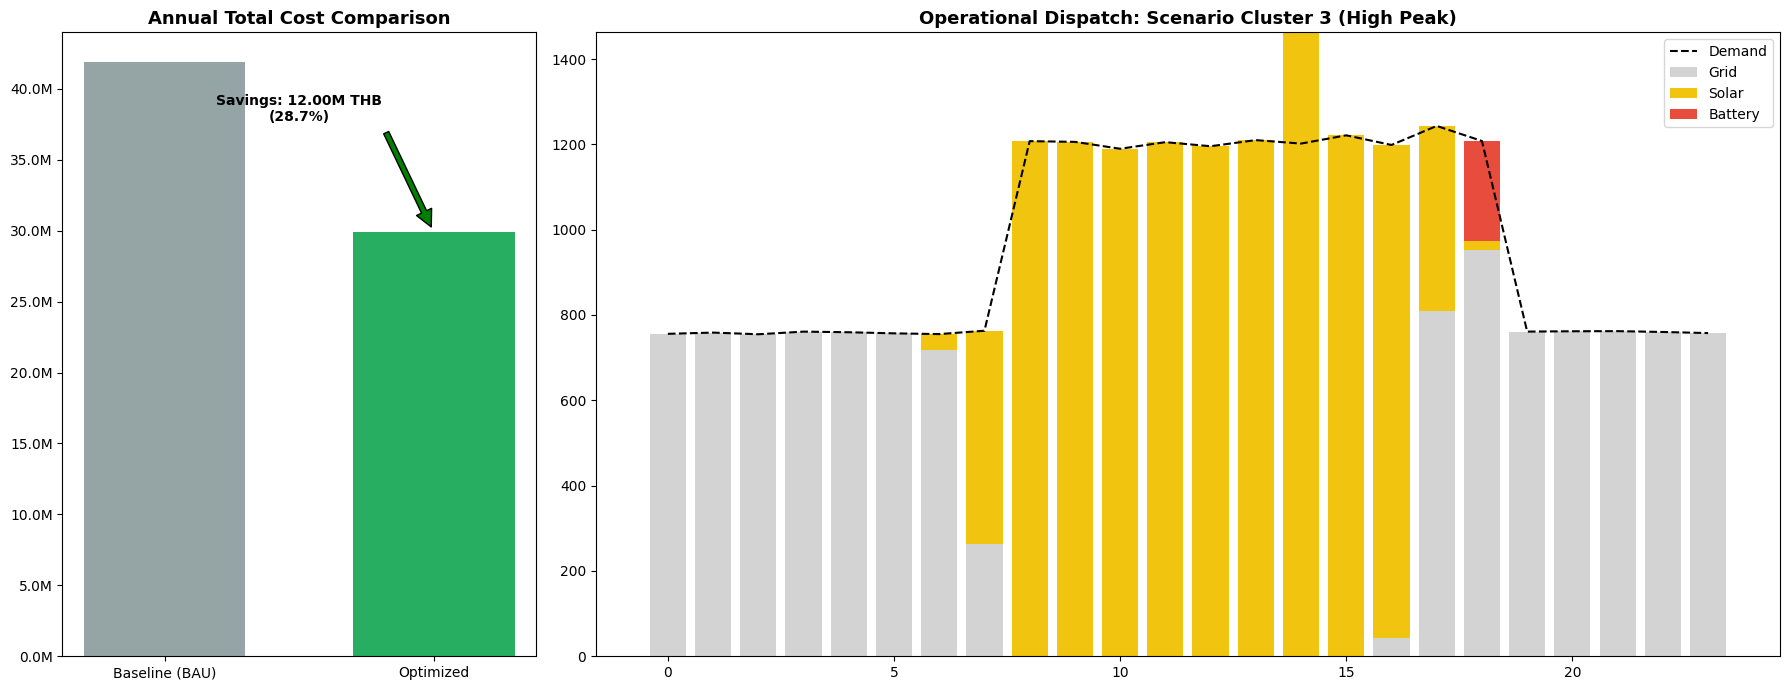

In [171]:
# Block 3: Decision & Visualization Suite
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_comprehensive_results(opt_res, base_res, scenarios_data):
    """Plots both financial comparison and operational dispatch."""

    # 1. Financial Feasibility Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 2.5]})

    # Bar Chart data
    labels = ['Baseline (BAU)', 'Optimized']
    costs = [base_res['Total_Cost'], opt_res['Total_Cost']]
    ax1.bar(labels, costs, color=['#95A5A6', '#27AE60'], width=0.6)
    ax1.set_title("Annual Total Cost Comparison", fontweight='bold')
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

    savings = base_res['Total_Cost'] - opt_res['Total_Cost']
    ax1.annotate(f'Savings: {savings/1e6:.2f}M THB\n({(savings/base_res["Total_Cost"])*100:.1f}%)',
                 xy=(1, opt_res['Total_Cost']), xytext=(0.5, base_res['Total_Cost']*0.9),
                 arrowprops=dict(facecolor='green', shrink=0.05), ha='center', fontweight='bold')

    # 2. Operational Dispatch (Example: Scenario omega_3 - High Risk)
    w_key = 'omega_3' # Focus on high peak scenario
    data = opt_res['Scenarios'][w_key]
    hr = np.arange(24)
    ax2.bar(hr, data['P_grid'], color='#d3d3d3', label='Grid')
    ax2.bar(hr, data['P_solar'], bottom=data['P_grid'], color='#F1C40F', label='Solar')
    ax2.bar(hr, data['P_dis'], bottom=np.array(data['P_grid'])+np.array(data['P_solar']), color='#E74C3C', label='Battery')
    ax2.plot(hr, scenarios_data[w_key]['demand_profile'], color='black', ls='--', label='Demand')
    ax2.set_title(f"Operational Dispatch: Scenario Cluster 3 (High Peak)", fontweight='bold')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# --- RUN EXECUTION ---
m_b, res_base = solve_strategic_microgrid(omega_scenarios, is_baseline=True)
m_o, res_opt = solve_strategic_microgrid(omega_scenarios, is_baseline=False)

plot_comprehensive_results(res_opt, res_base, omega_scenarios)

In [165]:
# Base
print(f'Optimal Solar Capacity: {pyo.value(m_b.S_solar):,.2f} kW')
print(f'Optimal Battery Capacity: {pyo.value(m_b.S_batt):,.2f} kWh')
print(f'Value at Risk (VaR): {pyo.value(m_b.zeta):,.2f} THB')
print(f'Final Objective Value: {pyo.value(m_b.Obj):,.2f} THB')

Optimal Solar Capacity: 0.00 kW
Optimal Battery Capacity: 0.00 kWh
Value at Risk (VaR): 41,950,707.99 THB
Final Objective Value: 41,886,351.60 THB


In [166]:
# Optimal
print(f'Optimal Solar Capacity: {pyo.value(m_o.S_solar):,.2f} kW')
print(f'Optimal Battery Capacity: {pyo.value(m_o.S_batt):,.2f} kWh')
print(f'Value at Risk (VaR): {pyo.value(m_o.zeta):,.2f} THB')
print(f'Final Objective Value: {pyo.value(m_o.Obj):,.2f} THB')

Optimal Solar Capacity: 3,365.92 kW
Optimal Battery Capacity: 247.73 kWh
Value at Risk (VaR): 30,787,181.36 THB
Final Objective Value: 29,881,384.06 THB


#### 2.4.4 Operational Dispatch Visualization

This block creates the hourly dispatch plots for the 3 clusters.

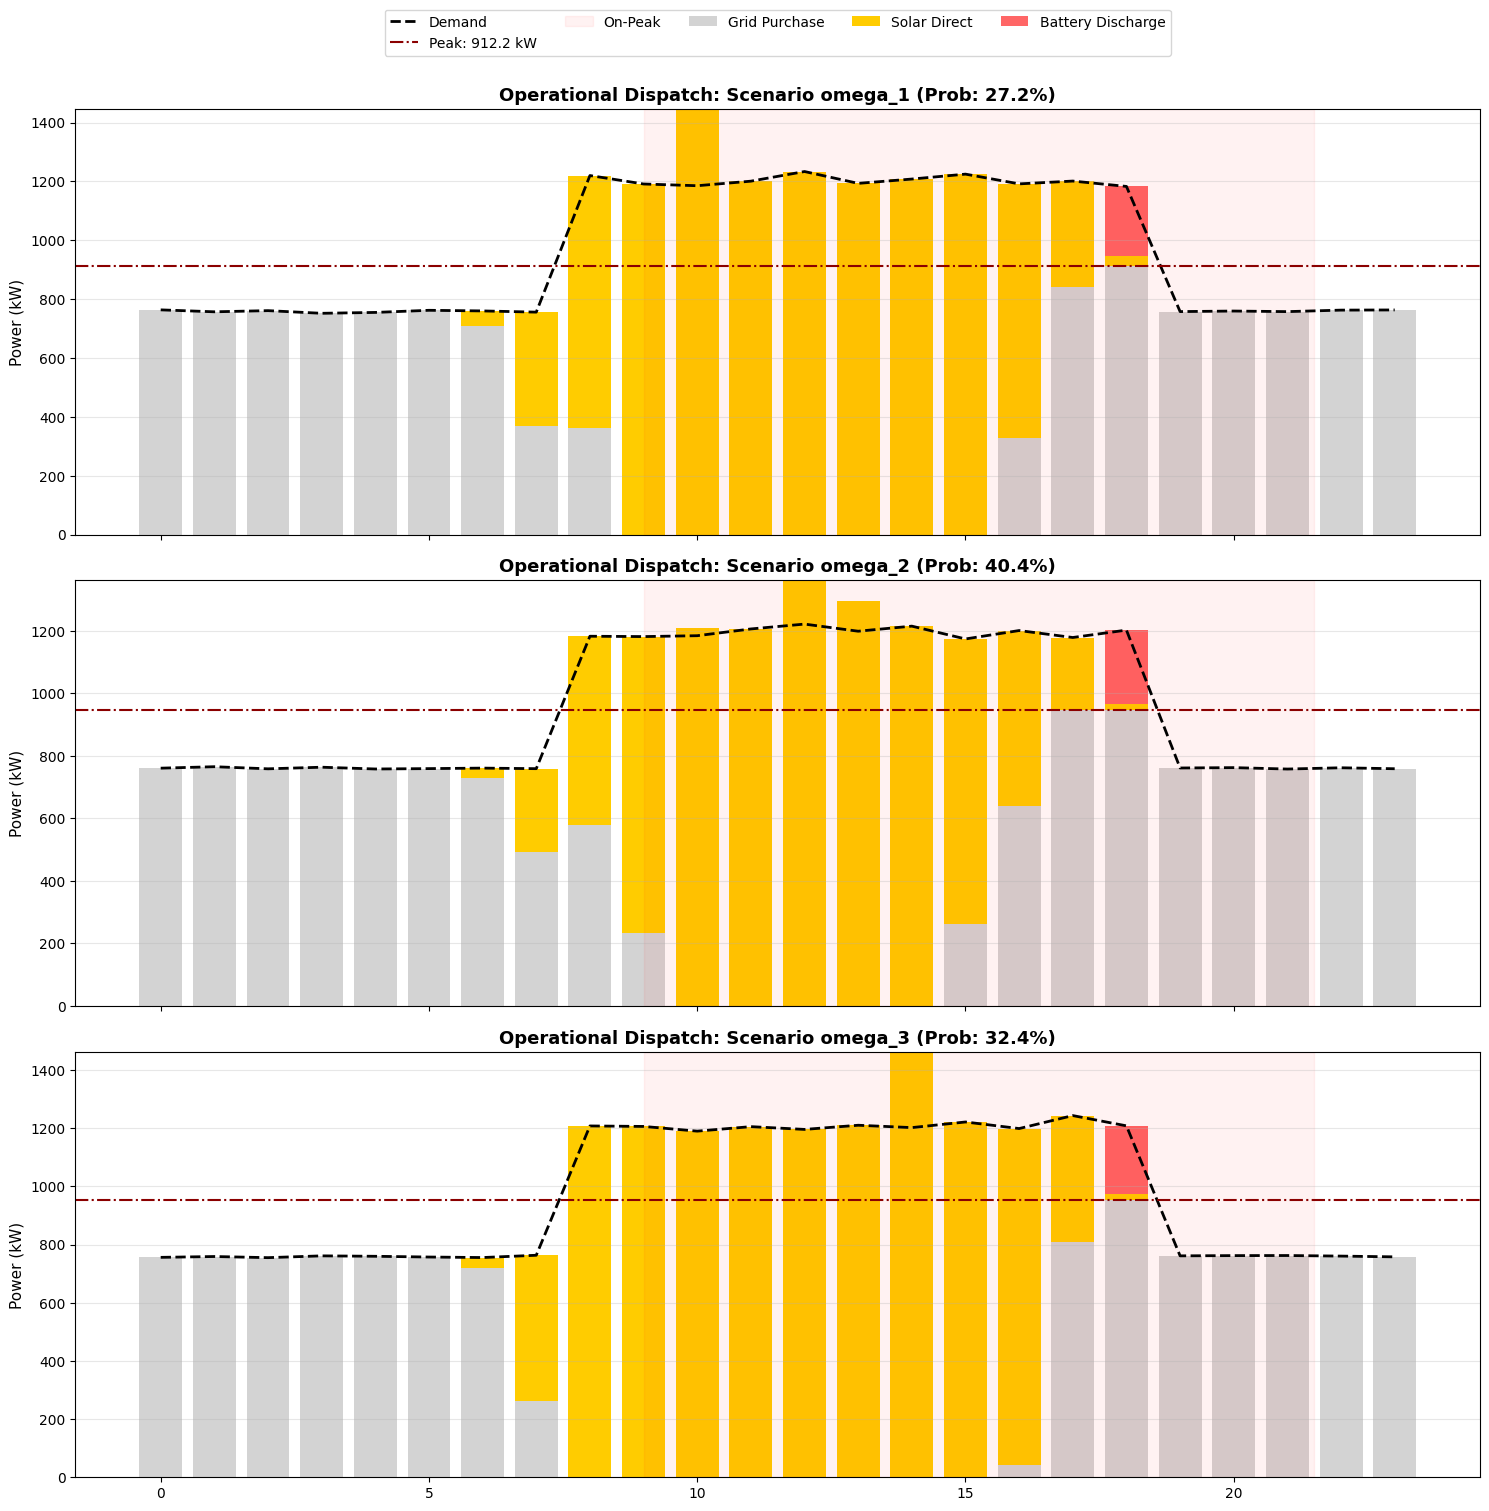

In [162]:
# Block 4: Daily Dispatch Plots (Scenario Slicing)
def plot_operational_dispatch(results_dict, scenarios_data):
    """Plots the hourly stacked bar dispatch for each scenario cluster."""
    scenarios = results_dict['Scenarios']
    fig, axes = plt.subplots(len(scenarios), 1, figsize=(15, 5 * len(scenarios)), sharex=True)
    colors = {'Grid': '#d3d3d3', 'Solar': '#ffcc00', 'Batt': '#ff6666'}

    for idx, (w, data) in enumerate(scenarios.items()):
        ax = axes[idx]
        hr = np.arange(24)

        # Plotting energy components
        ax.bar(hr, data['P_grid'], label='Grid Purchase', color=colors['Grid'])
        ax.bar(hr, data['P_solar'], bottom=data['P_grid'], label='Solar Direct', color=colors['Solar'])
        ax.bar(hr, data['P_dis'], bottom=np.array(data['P_grid'])+np.array(data['P_solar']), label='Battery Discharge', color=colors['Batt'])

        # Overlays
        ax.plot(hr, scenarios_data[w]['demand_profile'], color='black', ls='--', lw=2, label='Demand')
        ax.axhline(data['Peak'], color='darkred', ls='-.', label=f'Peak: {data["Peak"]:.1f} kW')
        ax.axvspan(9, 21.5, color='red', alpha=0.05, label='On-Peak')

        ax.set_title(f"Operational Dispatch: Scenario {w} (Prob: {scenarios_data[w]['probability']*100:.1f}%)", fontweight='bold')
        ax.set_ylabel("Power (kW)")
        ax.grid(axis='y', alpha=0.3)
        if idx == 0: ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=5)

    plt.tight_layout()
    plt.show()

# Execution
plot_operational_dispatch(res_opt, omega_scenarios)

#### 2.4.5 Sensitivity Analysis Suite

The 7-Factor sensitivity code with the improved 2-set visual layout.

<>:49: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_16264/1179368208.py:49: SyntaxWarning: invalid escape sequence '\l'
  titles2 = ["Demand Charge", "Risk Aversion ($\lambda$)"] # Removed Diesel cost


Overall Progress:   0%|          | 0/6 [00:00<?, ?it/s]

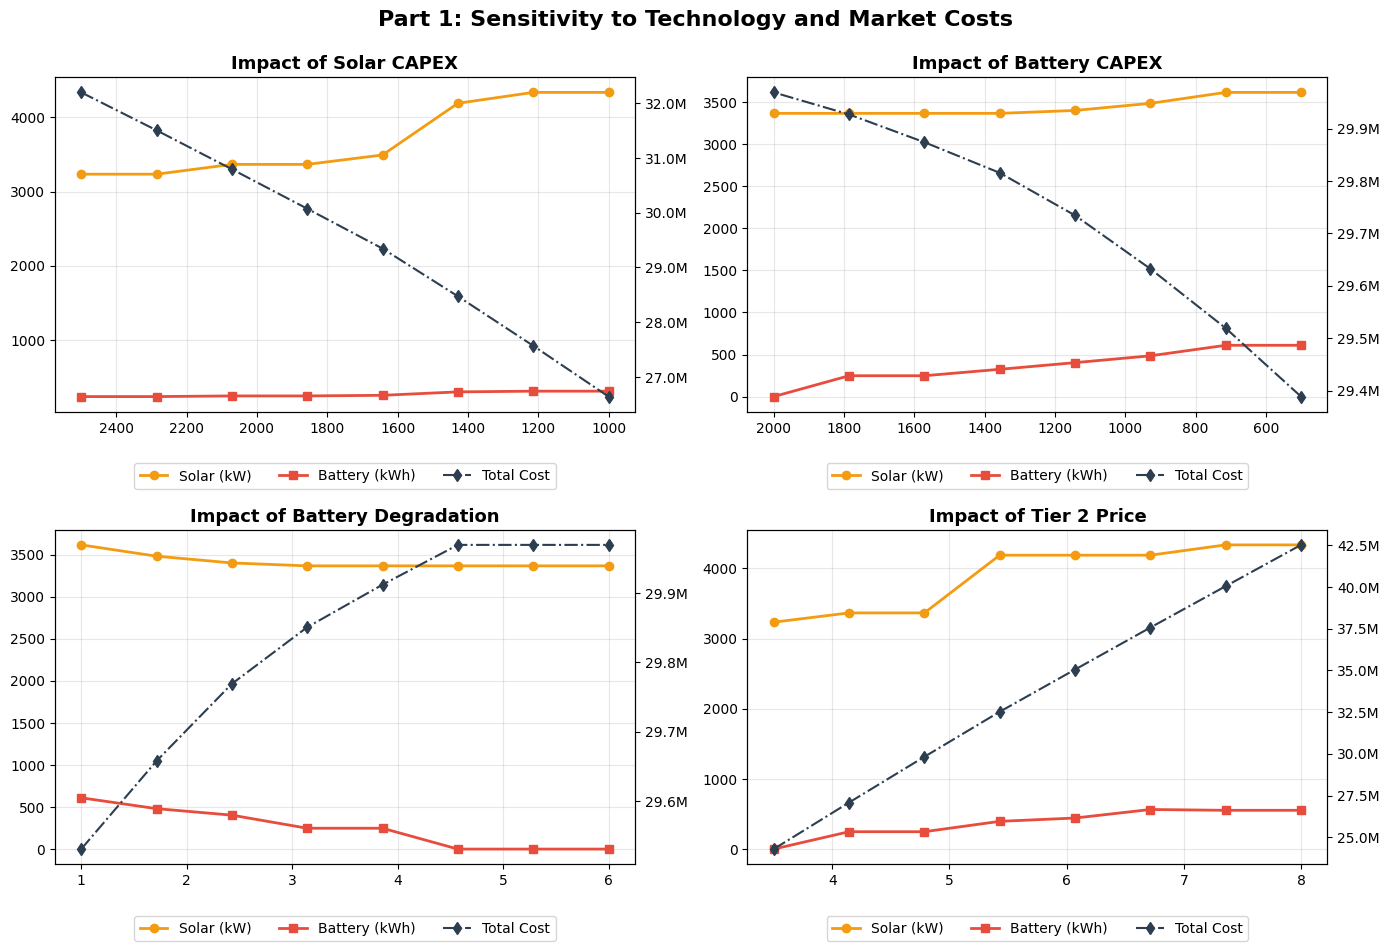

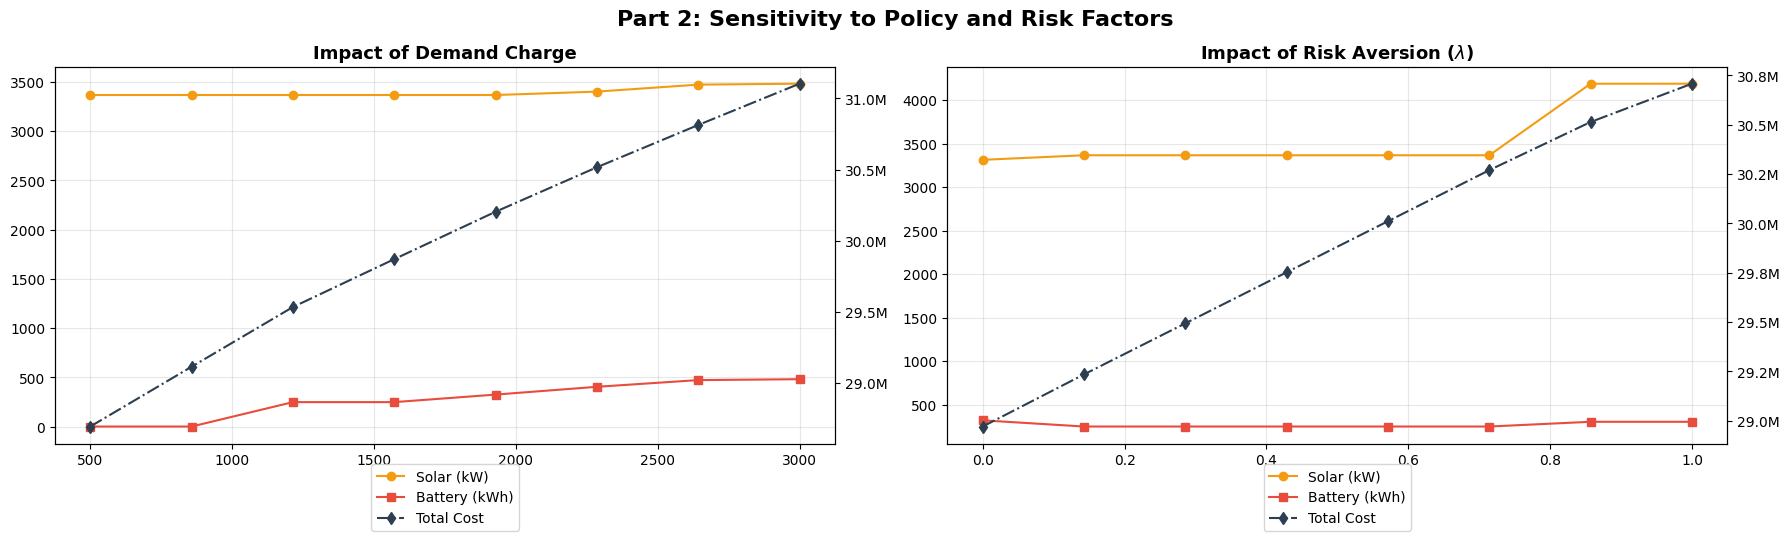

In [170]:
# Block 5: Sensitivity Analysis Suite
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.notebook import tqdm

# --- 5.1 Visualization: Multi-Factor Split Dashboards ---
def plot_professional_split_sensitivity(results):
    """
    Generates two publication-quality figures:
    Figure 1: Technology & Market Factors (2x2)
    Figure 2: Policy & Risk Factors (1x2 now, not 1x3)
    """
    plt.rcParams.update({'font.family': 'sans-serif', 'legend.fontsize': 10})
    keys = list(results.keys()) # This will now have 6 keys
    fmt_m = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

    # Colors
    c_sol, c_bat, c_cst, c_dsl = '#F39C12', '#E74C3C', '#2C3E50', '#8E44AD'

    # --- Part 1: Technology & Pricing (2x2) ---
    fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
    titles1 = ["Solar CAPEX", "Battery CAPEX", "Battery Degradation", "Tier 2 Price"]

    for i in range(4): # Loop for keys[0] to keys[3]
        ax1 = axes1.flatten()[i]
        df = pd.DataFrame(results[keys[i]])
        l1 = ax1.plot(df['x'], df['Solar_kW'], marker='o', color=c_sol, label='Solar (kW)', lw=2)
        l2 = ax1.plot(df['x'], df['Battery_kWh'], marker='s', color=c_bat, label='Battery (kWh)', lw=2)

        ax2 = ax1.twinx()
        l3 = ax2.plot(df['x'], df['Total_Cost'], marker='d', color=c_cst, ls='-.', label='Total Cost', lw=1.5)
        ax2.yaxis.set_major_formatter(fmt_m)

        ax1.set_title(f"Impact of {titles1[i]}", fontweight='bold')
        ax1.grid(True, alpha=0.3)
        if i < 2: ax1.invert_xaxis() # Capex decreasing trend

        lns = l1 + l2 + l3
        ax1.legend(lns, [l.get_label() for l in lns], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig1.suptitle("Part 1: Sensitivity to Technology and Market Costs", fontsize=16, fontweight='bold')
    plt.show()

    # --- Part 2: Policy & Risk (1x2, no diesel) ---
    fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6), facecolor='white') # Changed from 1, 3 to 1, 2
    titles2 = ["Demand Charge", r"Risk Aversion ($\lambda$)"] # Removed Diesel cost

    # Ensure axes2 is iterable even if it's a single subplot
    if len(titles2) == 1:
        axes2 = [axes2]

    for i in range(len(titles2)): # Loop for keys[4] to keys[5]
        ax1 = axes2[i]; idx = i + 4 # idx will be 4, 5
        df = pd.DataFrame(results[keys[idx]])
        l1 = ax1.plot(df['x'], df['Solar_kW'], marker='o', color=c_sol, label='Solar (kW)')
        l2 = ax1.plot(df['x'], df['Battery_kWh'], marker='s', color=c_bat, label='Battery (kWh)')

        ax2 = ax1.twinx()
        l3 = ax2.plot(df['x'], df['Total_Cost'], marker='d', color=c_cst, ls='-.', label='Total Cost')
        ax2.yaxis.set_major_formatter(fmt_m)

        ax1.set_title(f"Impact of {titles2[i]}", fontweight='bold')
        ax1.grid(True, alpha=0.3)
        lns = l1 + l2 + l3
        ax1.legend(lns, [l.get_label() for l in lns], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=1)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    fig2.suptitle("Part 2: Sensitivity to Policy and Risk Factors", fontsize=16, fontweight='bold') # Adjusted title
    plt.show()

# --- 5.2 Visualization: Professional Tornado Diagram ---
def plot_tornado_diagram_professional(sensitivity_results):
    """
    Summarizes the 'swing' impact of all factors on Total Lifecycle Cost.
    """
    tornado_data = []
    mapping = {
        'annual_capex_solar': 'Solar PV CAPEX',
        'annual_capex_batt': 'Battery ESS CAPEX',
        'C_deg': 'Battery Degradation',
        'tier2_price': 'Tier 2 Grid Price',
        'annual_demand_charge': 'Demand Charge Penalty',
        'lambda_risk': r'Risk Aversion ($\lambda$)'
    }

    for key, data_list in sensitivity_results.items():
        df = pd.DataFrame(data_list)
        tornado_data.append({
            'Factor': mapping.get(key, key),
            'Min': df['Total_Cost'].min(),
            'Max': df['Total_Cost'].max(),
            'Base': df['Total_Cost'].iloc[len(df)//2]
        })

    df_t = pd.DataFrame(tornado_data).sort_values(by='Max', ascending=True).reset_index()
    base_val = df_t['Base'].mean()

    fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
    ax.axvline(base_val, color='#E74C3C', lw=2, label='Baseline Cost')

    for i in range(len(df_t)):
        ax.barh(i, df_t['Max'].iloc[i] - df_t['Min'].iloc[i], left=df_t['Min'].iloc[i],
                color='#2980B9', alpha=0.9, height=0.6)
        # Labels
        ax.text(df_t['Min'].iloc[i], i, f" {df_t['Min'].iloc[i]/1e6:.1f}M", ha='right', va='center', fontsize=9)
        ax.text(df_t['Max'].iloc[i], i, f" {df_t['Max'].iloc[i]/1e6:.1f}M", ha='left', va='center', fontsize=9)

    ax.set_yticks(df_t.index)
    ax.set_yticklabels(df_t['Factor'], fontweight='bold')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
    ax.set_title("Tornado Diagram: Impact of Variables on Annual Cost", fontsize=15, fontweight='bold', loc='left')
    plt.grid(axis='x', alpha=0.2)
    plt.legend()
    plt.show()

# --- 5.3 Execution: Running the Sensitivity Engine ---
def run_fixed_sensitivity(omega_scenarios):
    factors = {
        'annual_capex_solar': np.linspace(1000, 2500, 8),
        'annual_capex_batt': np.linspace(500, 2000, 8),
        'C_deg': np.linspace(1.0, 6.0, 8),
        'tier2_price': np.linspace(3.5, 8.0, 8),
        'annual_demand_charge': np.linspace(500, 3000, 8),
        'lambda_risk': np.linspace(0.0, 1.0, 8)
    }

    results = {k: [] for k in factors.keys()}
    for key in tqdm(factors.keys(), desc="Overall Progress"):
        for val in factors[key]:
            kwargs = {'omega_scenarios': omega_scenarios}
            if key == 'annual_capex_solar': kwargs['annual_capex_solar'] = val
            elif key == 'annual_capex_batt': kwargs['annual_capex_batt'] = val
            elif key == 'C_deg': kwargs['C_deg'] = val
            elif key == 'tier2_price': kwargs['tier2_price'] = val
            elif key == 'annual_demand_charge': kwargs['annual_demand_charge'] = val
            elif key == 'lambda_risk': kwargs['lambda_risk'] = val

            _, res = solve_strategic_microgrid(**kwargs)
            results[key].append({'x': val, **res})
    return results

# Execute
ultimate_results = run_fixed_sensitivity(omega_scenarios)
plot_professional_split_sensitivity(ultimate_results)
plot_tornado_diagram_professional(ultimate_results)


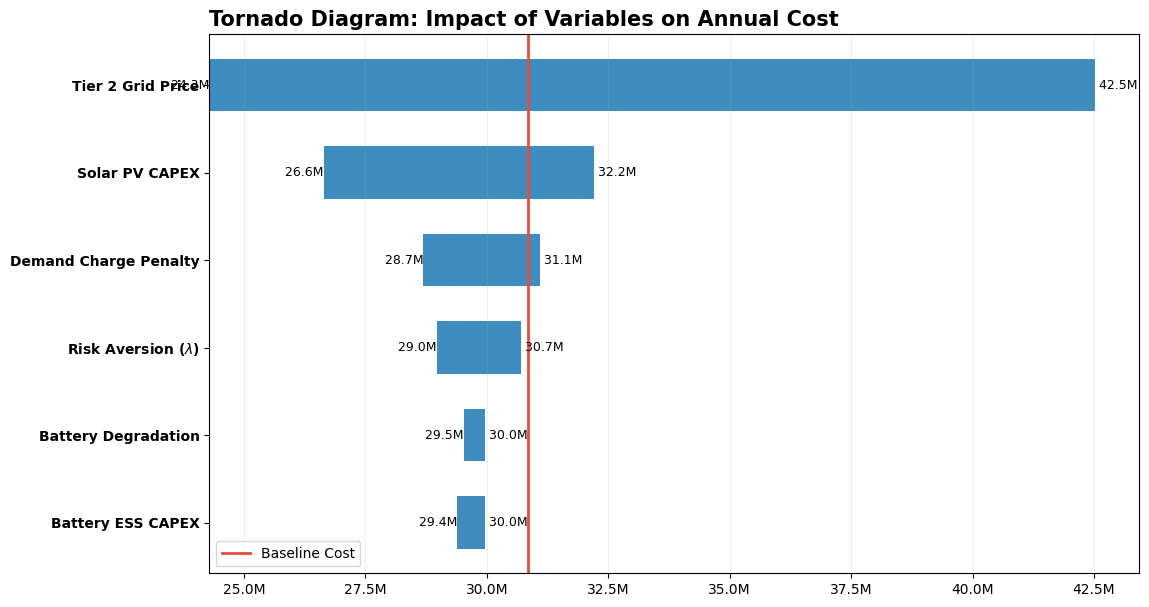

In [168]:
plot_tornado_diagram_professional(ultimate_results)